## Required Libraries 

In [627]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [628]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [629]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
import scipy.stats as stats
from scipy.stats import chi2_contingency

## Data Import 

In [630]:
import pandas as pd

# Load dataset
df = pd.read_csv("merged dataset.csv")  

# Look at first few rows
print(df.head())

   gravida  parity  gestational age (weeks)  Age (yrs)   bmi  diabetes  \
0        4       2                     26.0         22  17.2         1   
1        3       2                     30.0         29  21.2         0   
2        2       1                     26.2         25  31.2         0   
3        3       1                     22.2         27  21.0         0   
4        1       0                     22.1         24  26.8         1   

   History of hypertension   Systolic BP  Diastolic BP    HB  \
0                         0          130            80   8.5   
1                         0          110            60   8.3   
2                         0          110            70  10.8   
3                         0          110            70   9.3   
4                         0          120            80   8.0   

   fetal weight(kgs)  Protien Uria  amniotic fluid levels(cm)  Risk_level  
0              0.760             1                       14.5           1  
1              1.3

## Data Exploration

### Data Types Check

In [631]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 709 entries, 0 to 708
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gravida                    709 non-null    int64  
 1   parity                     709 non-null    int64  
 2   gestational age (weeks)    709 non-null    float64
 3   Age (yrs)                  709 non-null    int64  
 4   bmi                        709 non-null    float64
 5   diabetes                   709 non-null    int64  
 6   History of hypertension    709 non-null    int64  
 7   Systolic BP                709 non-null    int64  
 8   Diastolic BP               709 non-null    int64  
 9   HB                         709 non-null    float64
 10  fetal weight(kgs)          709 non-null    float64
 11  Protien Uria               709 non-null    int64  
 12  amniotic fluid levels(cm)  709 non-null    float64
 13  Risk_level                 709 non-null    int64  

### Null Values? 

In [632]:
# Check if there are any missing values in the entire DataFrame
print(df.isnull().values.any())

False


### Initial Checks

In [633]:
df.shape

(709, 14)

In [634]:
df.describe(include='all')

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Risk_level
count,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000,709.000000
mean,3.289140,1.593794,24.916361,27.327221,28.574189,0.201693,0.235543,118.466855,76.476728,10.575882,1.587144,0.214386,11.958801,0.423131
std,1.714728,1.548196,8.771191,5.389633,5.788128,0.401547,0.424637,14.927341,11.394373,1.389873,0.993632,0.410686,2.072089,0.494405
min,1.000000,0.000000,4.000000,18.000000,16.400000,0.000000,0.000000,90.000000,20.000000,8.000000,0.125000,0.000000,5.000000,0.000000
25%,2.000000,0.000000,20.000000,23.000000,25.000000,0.000000,0.000000,110.000000,70.000000,9.500000,0.696000,0.000000,10.550000,0.000000
50%,3.000000,1.000000,26.000000,27.000000,28.000000,0.000000,0.000000,119.000000,77.000000,10.500000,1.395600,0.000000,12.300000,0.000000
75%,4.000000,3.000000,32.000000,32.000000,32.000000,0.000000,0.000000,128.000000,82.000000,11.500000,2.500000,0.000000,13.700000,1.000000
max,9.000000,7.000000,40.000000,38.000000,43.300000,1.000000,1.000000,170.000000,110.000000,13.500000,3.760000,1.000000,15.000000,1.000000


### Numeric Distibutions of features

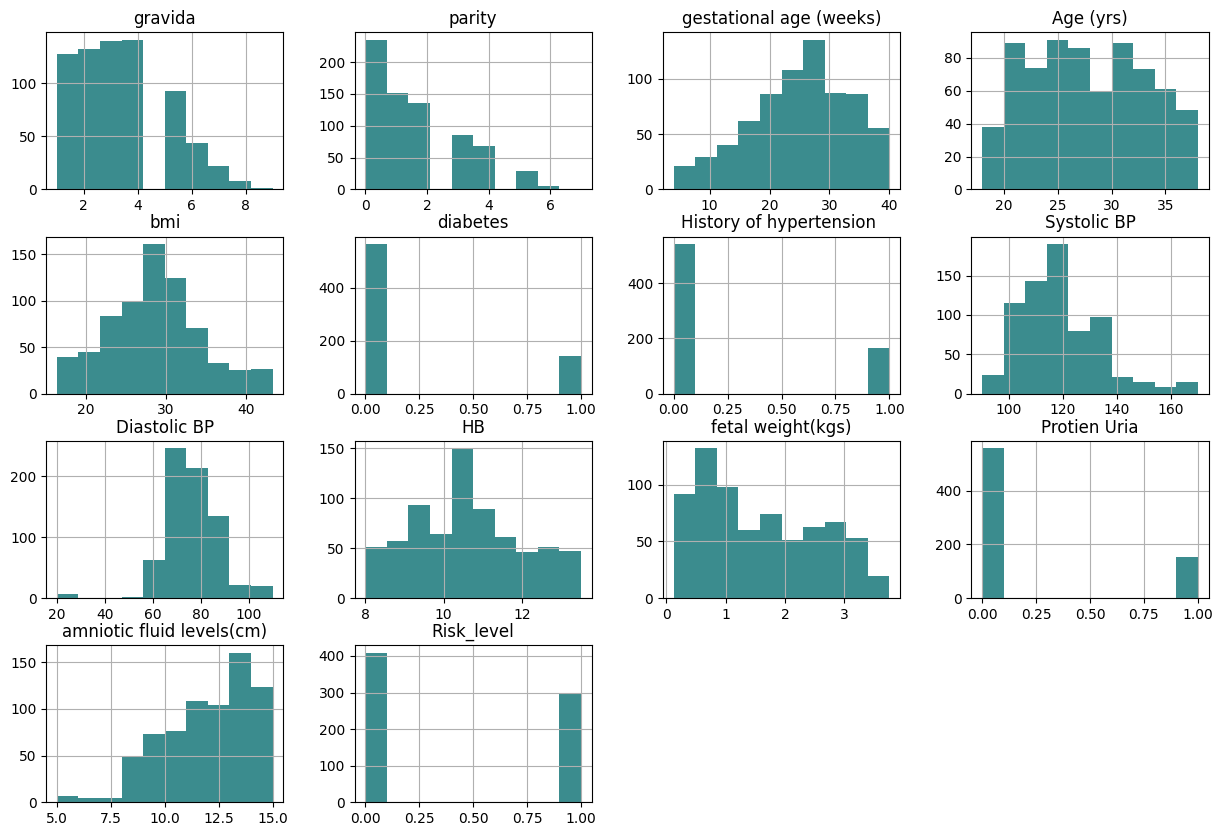

In [635]:
# Numeric distributions

df.hist(figsize=(15,10),color='#3b8c8e')
plt.show()


**Insights**

- Numeric variables (BMI, BP, HB, Fetal weight, Amniotic fluid) are mostly bell-shaped, but some outliers exist.
- Categorical/binary variables (Diabetes, Hypertension, Protein Urea, Risk_level) are highly skewed to 0.
- Potential outliers: Gravida (very high pregnancies), BMI (>40), BP (>160/100). 

**Implications**

- All outliers are medically plausible so they can remain as is, no need for intervention
- Further analysis required for analyzing impact of imbalance 

### Check for Features' Imbalance 

#### Distribution Stats vs Risk Level 

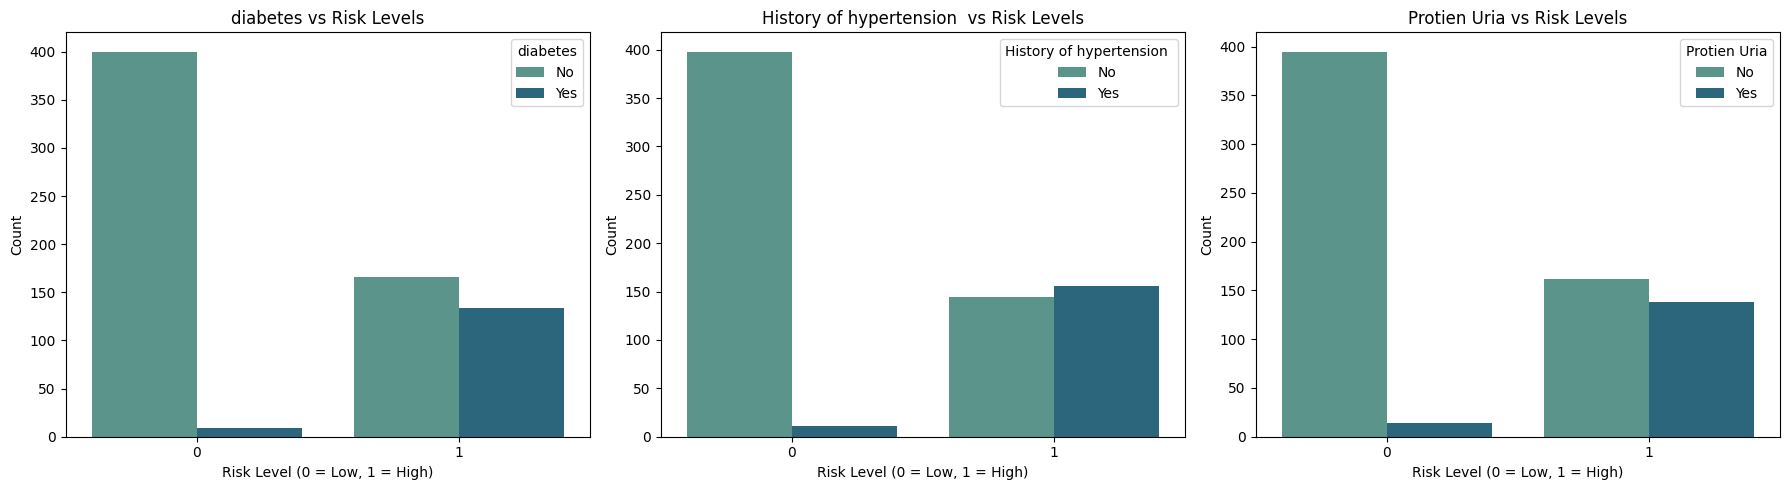

In [636]:
# features to plot
features = ["diabetes", "History of hypertension ", "Protien Uria"]

plt.figure(figsize=(18,5))  # wider for 3 plots

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x='Risk_level', hue=feature, data=df, 
                  palette='crest')
    plt.title(f"{feature} vs Risk Levels")
    plt.xlabel("Risk Level (0 = Low, 1 = High)")
    plt.ylabel("Count")
    plt.legend(title=feature, labels=['No','Yes'])

plt.tight_layout()
plt.show()


#### Value Counts' Assessment 

In [637]:

# pick binary categorical columns

binary_cols = [col for col in df.columns if df[col].nunique() == 2]

# build summary with spacer rows
summary = []

for col in binary_cols:
    counts = df[col].value_counts()
    percentages = (counts / counts.sum() * 100).round(2)
    temp = pd.DataFrame({
        "Feature": col,
        "Value": counts.index,
        "Count": counts.values,
        "Percentage": percentages.values
    })
    summary.append(temp)
    
    # add spacer row
    summary.append(pd.DataFrame({"Feature": [""], "Value": [""], "Count": [""], "Percentage": [""]}))

# combine into one table
summary_df = pd.concat(summary, ignore_index=True)

print(summary_df)


                     Feature Value Count Percentage
0                   diabetes     0   566      79.83
1                   diabetes     1   143      20.17
2                                                  
3   History of hypertension      0   542      76.45
4   History of hypertension      1   167      23.55
5                                                  
6               Protien Uria     0   557      78.56
7               Protien Uria     1   152      21.44
8                                                  
9                 Risk_level     0   409      57.69
10                Risk_level     1   300      42.31
11                                                 


**Implication**

- Data reflects real-life prevalance (most people dont end up having diabetes)
- Imbalance in features is only problematic when target label is imbalanced, we need to look into it and refer back
- Mostly positives contribute to a postive risk level, which implies that as far as target is not imbalanced, its strong association is evident


### Assessing Target Imbalance 

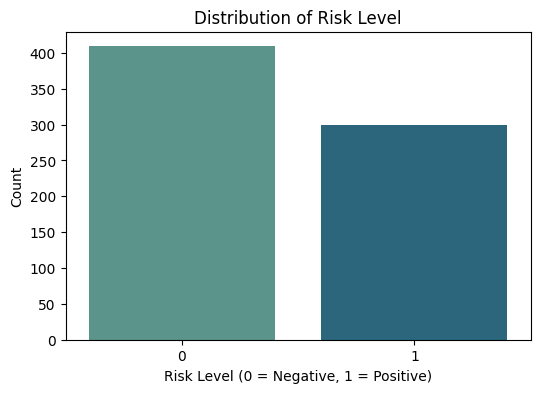

In [638]:

plt.figure(figsize=(6,4))
sns.countplot(x='Risk_level', data=df, palette='crest', hue="Risk_level",legend=False )

plt.title("Distribution of Risk Level")
plt.xlabel("Risk Level (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

- Risk_level = 0 -- ~400 samples
- Risk_level = 1 -- ~300 samples

Ratio ≈ 57% vs 43%

This is fairly balanced. No need for aggressive rebalancing. 


## Correlation Matrix - first glimpse into feature relations

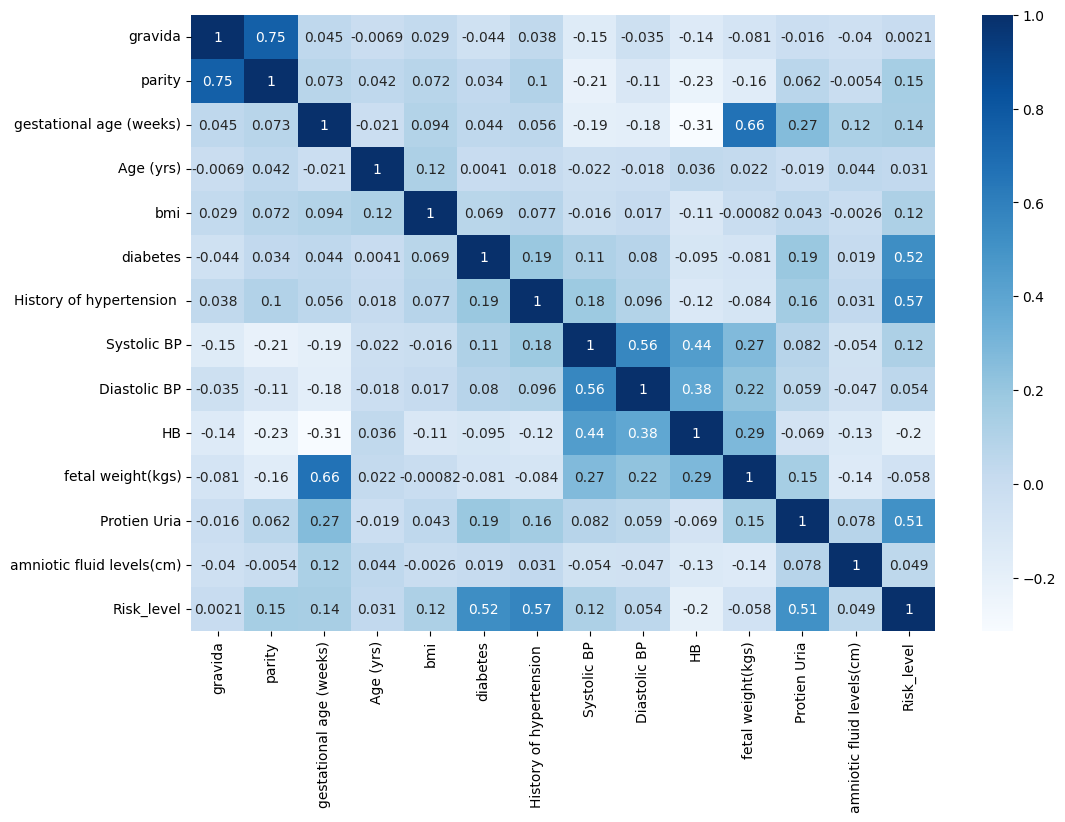

In [639]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

### Key Observations

##### General

**Gravida & Parity (0.75)**
- Very strongly correlated. Makes sense: more pregnancies usually imply more live births.
- Might be redundant to keep both in models (multicollinearity).

**Gestational age & Fetal weight (0.66)**
- Higher gestational weeks → higher fetal weight. Biologically correct.
- Strong positive correlation.

**Systolic & Diastolic BP (0.56)**
- Blood pressures rise together (as expected).



##### Risk_level Correlations (target column):

- **History of Hypertension (0.57):** Strongest positive correlation with pre-eclampsia risk.
- **Diabetes (0.52):** Also strongly associated with higher risk.
- **Proteinuria (0.51)** → strong association


Small Positive Association:
- Parity (0.15): Small positive relation (slightly higher risk with more pregnancies).
- Gestational Weeks (0.14)
- Systolic BP, BMI (~0.12 each): Weak but positive relation.

Negative Correlation: 
- Fetal weight (−0.20) → Negative correlation → lower fetal weight tends to appear in positive cases.
- Hemoglobin (HB, −0.20) → Lower HB mildly associated with higher risk.

Weak links
- Gravida (pregnancies overall) has near zero correlation with risk.
- Amniotic fluid levels (~0.05) → very weak link with risk.

### Key Contributors

- Diabetes, History of hypertension and protien uria - all have clear correlation with target
- Being categorical binary features implies that while further feature engineering can contribiute with these factors, these will always remain essential in pre-eclampsia predictions  

- Remaining features will be processed further with feature engineering techniques to analyze complete impact 

## Feature Engineering 

### Calculating Pregnancy Losses through Gravida/Parity to analyze impact 

In [640]:
df["Pregnancy_Losses"] = df["gravida"] - df["parity"] 
# Move Risk_Level to the end 
risk = df.pop("Risk_level") 
df["Risk_level"] = risk

In [641]:
df.head()

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Pregnancy_Losses,Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.760,1,14.5,2,1
1,3,2,30.0,29,21.2,0,0,110,60,8.3,1.319,0,13.2,1,0
2,2,1,26.2,25,31.2,0,0,110,70,10.8,0.784,0,14.4,1,0
3,3,1,22.2,27,21.0,0,0,110,70,9.3,0.510,0,13.2,2,0
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.505,1,13.1,1,1


In [642]:
df["Pregnancy_Losses"].describe()

count    709.000000
mean       1.695346
std        1.153596
min       -2.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: Pregnancy_Losses, dtype: float64

**Implication**
Min Pregnancy losses cannot be negative, this implies that parity>gravida which is not medically plausible so we consider such data entries as invalid and drop rows 

#### Removing Invalid Rows 

In [643]:

# Keep a backup before cleaning
df_original = df.copy()

# Define conditions for invalid rows
invalid_mask = df["Pregnancy_Losses"] < 0

# Show invalid rows (if any)
invalid_rows = df[invalid_mask]
if not invalid_rows.empty:
    print("Invalid rows detected (gravida/parity mismatch or negative values):")
    print(invalid_rows)
else:
    print("No invalid rows found.")

print(f"\nRows before cleaning: {len(df)}")

# Drop invalid rows
df = df[~invalid_mask].copy()

print(f"Rows after cleaning: {len(df)}")


Invalid rows detected (gravida/parity mismatch or negative values):
     gravida  parity  gestational age (weeks)  Age (yrs)   bmi  diabetes  \
88         3       4                     27.0         35  30.9         0   
110        3       5                     20.3         20  20.4         1   
225        1       3                     26.0         21  27.3         1   
226        1       2                     29.2         21  41.5         1   

     History of hypertension   Systolic BP  Diastolic BP    HB  \
88                          1          110            60   8.9   
110                         0          120            90   8.9   
225                         0          110            70  10.8   
226                         1          120            70  10.2   

     fetal weight(kgs)  Protien Uria  amniotic fluid levels(cm)  \
88              0.8800             1                      14.00   
110             0.4320             1                      11.30   
225             0.7

#### Count Plot to analyze impact with Risk_level Groups (0/1)

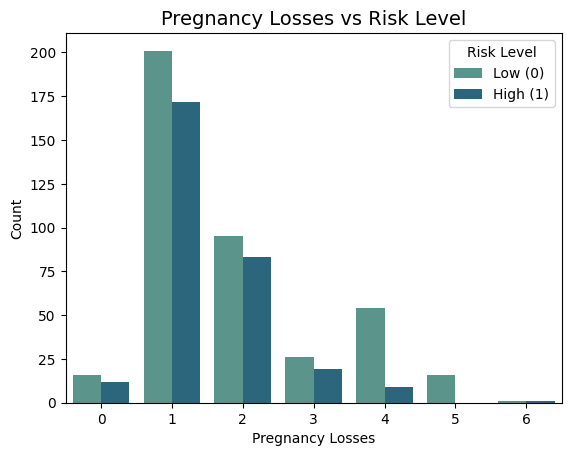

In [644]:

sns.countplot(
    x="Pregnancy_Losses", 
    hue="Risk_level", 
    data=df, 
    palette="crest"
)

plt.title("Pregnancy Losses vs Risk Level", fontsize=14)
plt.xlabel("Pregnancy Losses")
plt.ylabel("Count")
plt.legend(title="Risk Level", labels=["Low (0)", "High (1)"])
plt.show()


##### Cross Tab Percentages 

In [645]:
# Normalized cross-tab (row-wise) in percentages
map_crosstab_percent = pd.crosstab(
    df["Pregnancy_Losses"], 
    df["Risk_level"], 
    normalize="index"
) * 100

print(map_crosstab_percent.round(2))

Risk_level             0      1
Pregnancy_Losses               
0                  57.14  42.86
1                  53.89  46.11
2                  53.37  46.63
3                  57.78  42.22
4                  85.71  14.29
5                 100.00   0.00
6                  50.00  50.00


##### Implications

**Distribution of Pregnancy Losses**
- Majority of women have 1 or 2 pregnancy losses.

**Relationship with Risk Level**
- For 0–3 losses, both risk levels (0 = low, 1 = high) are fairly close, although low risk is slightly higher across all these categories.
- At 1 loss (the largest group), risk is almost evenly split between low and high — suggesting pregnancy losses may have some association with higher risk.
- At 4+ losses, low risk dominates strongly, but the counts are quite small, so it might not be statistically strong.

Let's dive further to gather statistical association for the feature.

#### Statistical Association - Chi-Square test

In [646]:

# Create contingency table
contingency_table = pd.crosstab(df["Pregnancy_Losses"], df["Risk_level"])

# Run chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

if p < 0.05:
    print("\nSignificant association: Pregnancy_Losses and Risk_level are dependent.")
else:
    print("\nNo significant association: Pregnancy_Losses and Risk_level are independent.")


Chi-square Statistic: 35.67122272996414
Degrees of Freedom: 6
P-value: 3.1933332998806294e-06

Significant association: Pregnancy_Losses and Risk_level are dependent.


In [647]:
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))
print("Cramer's V:", cramers_v)

Cramer's V: 0.22493883401848275


#### Key Observations:

Pregnancy losses are significantly associated with risk level (Chi-square p < 0.001), but the strength of association (Cramer’s V = 0.2) is modest. This suggests that while pregnancy losses matter, they should be considered alongside other clinical factors.

### Deriving MAP (Mean Arterial Pressure) from BP Readings 

In [648]:
#Create Mean Arterial Pressure (MAP) as well
df['MAP'] = (2*df['Diastolic BP'] + df['Systolic BP']) / 3
df['MAP']=df['MAP'].round(2)

# Move Risk_Level to the end 
risk = df.pop("Risk_level") 
df["Risk_level"] = risk


In [649]:
df.head()

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Pregnancy_Losses,MAP,Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.760,1,14.5,2,96.67,1
1,3,2,30.0,29,21.2,0,0,110,60,8.3,1.319,0,13.2,1,76.67,0
2,2,1,26.2,25,31.2,0,0,110,70,10.8,0.784,0,14.4,1,83.33,0
3,3,1,22.2,27,21.0,0,0,110,70,9.3,0.510,0,13.2,2,83.33,0
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.505,1,13.1,1,93.33,1


In [650]:
df['MAP'].describe()

count    705.000000
mean      90.494823
std       11.181141
min       46.670000
25%       83.330000
50%       90.000000
75%       96.330000
max      126.330000
Name: MAP, dtype: float64

#### Analyzing initial Pearson Correlation of MAP and Risk_Level

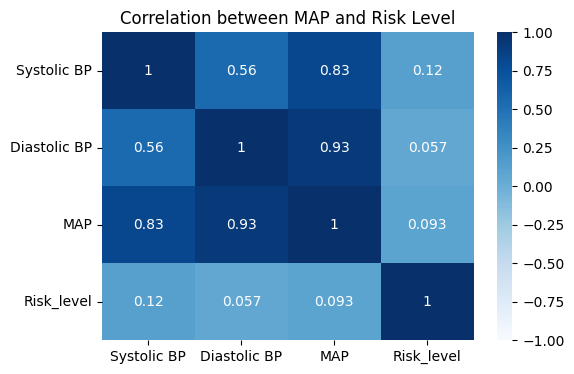

In [651]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["Systolic BP", "Diastolic BP", "MAP", "Risk_level"]].corr(method="pearson"), 
    annot=True, cmap="Blues", vmin=-1, vmax=1
)
plt.title("Correlation between MAP and Risk Level")
plt.show()

#### Dropping Features - Systolic and Diastolic BP  

**Feature–Feature Correlation (Multicollinearity)**
- Both predictors (Systolic and Diastolic) are highly correlated with MAP (0.8 and 0.9), and don’t seem to add new information.

**Feature–Target Correlation**
- Both have weak correlation, rather negligible in case of Diastolic BP, we will be analyzing impact (combined) through MAP 


In [652]:
df.head()

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Pregnancy_Losses,MAP,Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.760,1,14.5,2,96.67,1
1,3,2,30.0,29,21.2,0,0,110,60,8.3,1.319,0,13.2,1,76.67,0
2,2,1,26.2,25,31.2,0,0,110,70,10.8,0.784,0,14.4,1,83.33,0
3,3,1,22.2,27,21.0,0,0,110,70,9.3,0.510,0,13.2,2,83.33,0
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.505,1,13.1,1,93.33,1


In [653]:
df_original_2 = df.copy()

In [654]:
df.pop("Systolic BP")

0      130
1      110
2      110
3      110
4      120
      ... 
704    137
705    124
706    138
707    130
708    114
Name: Systolic BP, Length: 705, dtype: int64

In [655]:
df.pop("Diastolic BP")

0      80
1      60
2      70
3      70
4      80
       ..
704    72
705    88
706    71
707    76
708    71
Name: Diastolic BP, Length: 705, dtype: int64

In [656]:
df.head()

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Pregnancy_Losses,MAP,Risk_level
0,4,2,26.0,22,17.2,1,0,8.5,0.760,1,14.5,2,96.67,1
1,3,2,30.0,29,21.2,0,0,8.3,1.319,0,13.2,1,76.67,0
2,2,1,26.2,25,31.2,0,0,10.8,0.784,0,14.4,1,83.33,0
3,3,1,22.2,27,21.0,0,0,9.3,0.510,0,13.2,2,83.33,0
4,1,0,22.1,24,26.8,1,0,8.0,0.505,1,13.1,1,93.33,1


#### Binning MAP in categories to see impact on each group 

**Clinical Reference Ranges for MAP**
- Low MAP (< 60 mmHg): Hypoperfusion risk
- Normal MAP (70 – 100 mmHg): Adequate tissue perfusion
- High MAP (100 – 110 mmHg): Elevated risk
- Severe Hypertension (> 110 mmHg): Very high risk

**References**
- https://www.ncbi.nlm.nih.gov/books/NBK538226/
- https://www.ebsco.com/research-starters/health-and-medicine/mean-arterial-pressure-map

In [657]:
# Example reference bins and labels
map_bins = [0, 60, 70, 100, 110, float("inf")]
map_labels = ["Extreme Low", "Low", "Normal", "High", "Severe"]

# Create new binned column
df["MAP_Category"] = pd.cut(df["MAP"], bins=map_bins, labels=map_labels, right=False)

# Move Risk_Level to the end 
risk = df.pop("Risk_level") 
df["Risk_level"] = risk

# Check distribution
print(df["MAP_Category"].value_counts())


MAP_Category
Normal         600
High            55
Severe          43
Extreme Low      7
Low              0
Name: count, dtype: int64


#### Distribution of MAP Categories vs Risk Level

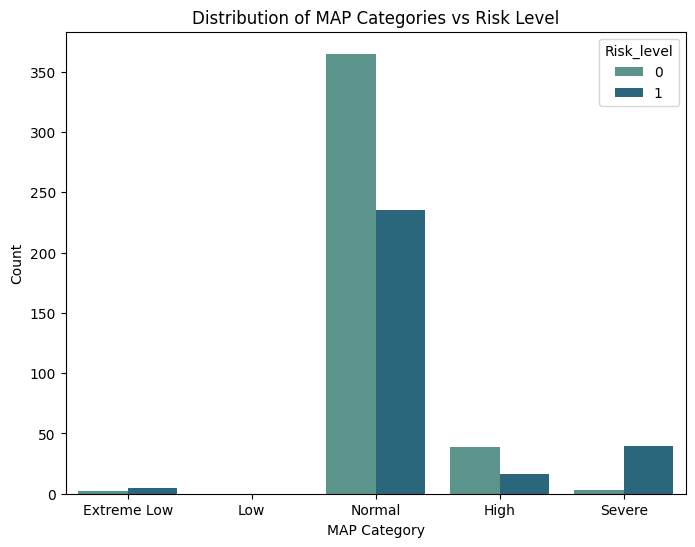

In [658]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="MAP_Category",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of MAP Categories vs Risk Level")
plt.xlabel("MAP Category")
plt.ylabel("Count")
plt.show()


In [659]:
# Cross-tab of MAP bins vs Risk_level
map_crosstab = pd.crosstab(df["MAP_Category"], df["Risk_level"])
print(map_crosstab)


Risk_level      0    1
MAP_Category          
Extreme Low     2    5
Normal        365  235
High           39   16
Severe          3   40


In [660]:
# Normalized cross-tab (row-wise) in percentages
map_crosstab_percent = pd.crosstab(
    df["MAP_Category"], 
    df["Risk_level"], 
    normalize="index"
) * 100

print(map_crosstab_percent.round(2))


Risk_level        0      1
MAP_Category              
Extreme Low   28.57  71.43
Normal        60.83  39.17
High          70.91  29.09
Severe         6.98  93.02


#### Key Obeservations

**Extreme Low (MAP < 60 mmHg)**
- 71% identify as high risk
- Suggests that very low MAP is strongly associated with risk. Most patients in this range fall into the risk group.
- However, cross-tab shows very less population for group ~7 which questions the hypostheses 

**Normal (70–100 mmHg)**
- 61% Risk identify as low risk
- Suggests for normal range, majority are not at risk. Fits clinical expectations.

**High (101–120 mmHg)**
- 71% Risk identify as low risk
- Higher-than-normal MAP still aligns with being safer for most patients as gathered for dataset.
- Suggests slightly elevated MAP is not as dangerous a threat for pre-eclampsia

**Severe (>110 mmHg)**
- 93% Risk identify as high risk 
- Suggests extremely high MAP is very strongly associated with risk.

*The relationship looks U-shaped → risk is low in the middle and increases at both extreme*

#### Visualization of Relationship

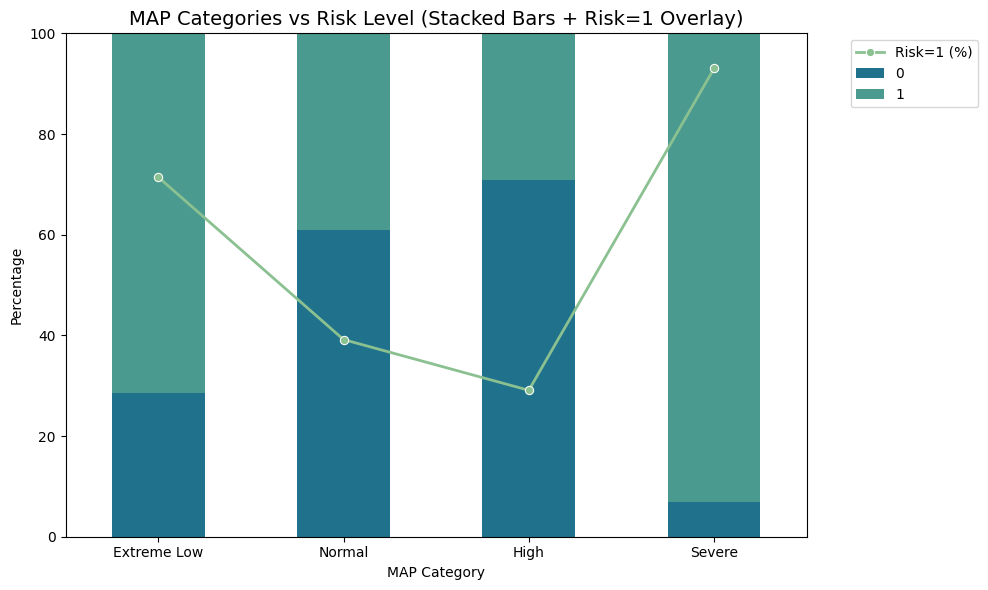

In [661]:

# Percentage cross-tab
map_crosstab_percent = pd.crosstab(
    df["MAP_Category"], df["Risk_level"], normalize="index"
) * 100

# Ensure consistent category order
category_order = ["Extreme Low", "Normal", "High", "Severe"]
map_crosstab_percent = map_crosstab_percent.reindex(category_order)

# Extract Risk=1 percentages for line
risk1_percent = map_crosstab_percent[1].reset_index()

plt.figure(figsize=(10,6))
colors = ["#20718b", "#4a9a8f"]  # blue & orange (clear contrast)
# --- Stacked Bars ---
map_crosstab_percent.plot(
    kind="bar", stacked=True, color=colors, ax=plt.gca()
)

# --- Overlay Line ---
sns.lineplot(
    data=risk1_percent,
    x="MAP_Category",
    y=1,
    marker="o",
    color="#8bc191",
    linewidth=2,
    label="Risk=1 (%)"
)

# Formatting
plt.title("MAP Categories vs Risk Level (Stacked Bars + Risk=1 Overlay)", fontsize=14)
plt.ylabel("Percentage")
plt.xlabel("MAP Category")
plt.ylim(0, 100)
plt.xticks(rotation=0)  # keep labels aligned
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


#### Statistical Association - Chi-Square Test

In [662]:
# Cross-tab
ct = pd.crosstab(df["MAP_Category"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")


Chi-square: 54.19
Degrees of Freedom: 3
P-value: 1.0232e-11
Cramer's V: 0.277


##### Interpretation

- p-value is extremely low which indicates statistically significant relationship between MAP_Category and Risk_level
- ~0.3 Cramers indicate **moderate association strength**
- "MAP is associated with Risk, but it’s not the sole driver — it’s one of several contributing factors."


### Fetal Weights groups based on Gestational Age

**References**
- https://journals.plos.org/plosmedicine/article/figure?id=10.1371/journal.pmed.1002220.t011

#### Data Import and Cleaning

In [663]:
centiles = pd.read_csv("fetal_weight_centiles.csv")

In [664]:
centiles.head()

,Gestational Age (weeks)\Percentiles,2.5,5,10,25,50,75,90,95,97.5
0,14,70,73,78,83,90,98,104,109,113
1,15,89,93,99,106,114,124,132,138,144
2,16,113,117,124,133,144,155,166,174,181
3,17,141,146,155,166,179,193,207,217,225
4,18,174,181,192,206,222,239,255,268,278


In [665]:
# Rename gestational age column
centiles.rename(columns={"Gestational Age (weeks)\\Percentiles": "GA"}, inplace=True)

# Make sure GA is integer
centiles["GA"] = centiles["GA"].astype(int)

print(centiles.dtypes)


GA      int64
2.5     int64
5       int64
10      int64
25      int64
50      int64
75      int64
90      int64
95      int64
97.5    int64
dtype: object


#### Groups' Classification

In [666]:
def classify_fetal_weight(row, centiles_df):
    ga = int(row["gestational age (weeks)"])
    weight = row["fetal weight(kgs)"] * 1000  # convert kg → g
    
    # Lookup thresholds
    ref = centiles_df[centiles_df["GA"] == ga]
    if ref.empty:
        return "Unknown"
    
    p10 = ref["10"].values[0]
    p90 = ref["90"].values[0]
    
    if weight < p10:
        return "SGA"
    elif weight > p90:
        return "LGA"
    else:
        return "AGA"


In [667]:
df["FetalWeight_Category"] = df.apply(lambda r: classify_fetal_weight(r, centiles), axis=1)

# Check distribution
print(df["FetalWeight_Category"].value_counts())

FetalWeight_Category
AGA        292
LGA        292
Unknown     85
SGA         36
Name: count, dtype: int64


#### Distribution of Fetal Weight Categories vs Risk Level

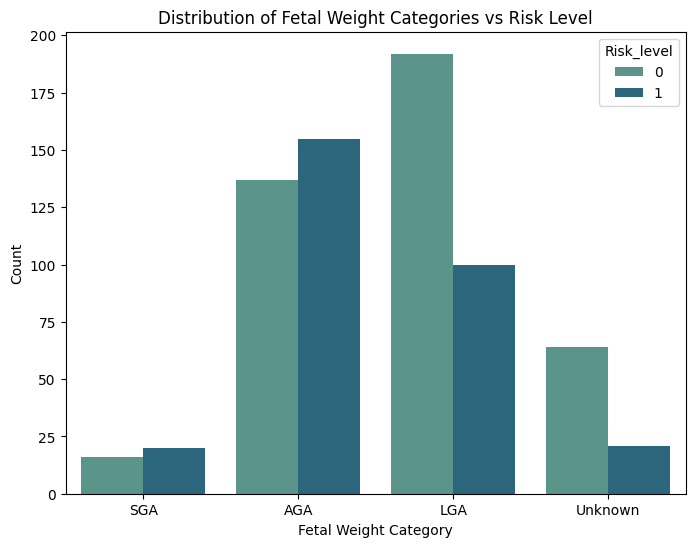

In [668]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="FetalWeight_Category",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of Fetal Weight Categories vs Risk Level")
plt.xlabel("Fetal Weight Category")
plt.ylabel("Count")
plt.show()

In [669]:
pd.crosstab(df["FetalWeight_Category"], df["Risk_level"], normalize="index") * 100


Risk_level,0,1
FetalWeight_Category,,
AGA,46.917808,53.082192
LGA,65.753425,34.246575
SGA,44.444444,55.555556
Unknown,75.294118,24.705882


#### Statistical Association - Chi-Square Test

In [670]:
# Cross-tab
ct = pd.crosstab(df["FetalWeight_Category"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 35.08
Degrees of Freedom: 3
P-value: 1.1703e-07
Cramer's V: 0.223


#### Interpretation

- p-value is low which indicates statistically significant relationship between FetalWeight_Category and Risk_level
- ~0.2 Cramers indicate weak association strength
- "associated with Risk, but not the sole driver — one of several contributing factors."

**AGA (Appropriate for Gestational Age):** ~47% low risk, ~53% high risk
- Nearly balanced, but slightly higher risk.

**LGA (Large for Gestational Age):** ~66% low risk, ~34% high risk
- These seem comparatively protective against high risk.

**SGA (Small for Gestational Age):** ~44% low risk, ~56% high risk
- Higher chance of risk, consistent with clinical knowledge as SGA often linked to complications).

#### Hypothesis 

In [671]:
count_under_14 = (df["gestational age (weeks)"] < 14).sum()
total_count = len(df)

proportion = count_under_14 / total_count * 100

print(f"Rows < 14 weeks: {count_under_14} ({proportion:.2f}%)")

Rows < 14 weeks: 85 (12.06%)


- No data is available for <14 weeks (GA), first trimester data lacks precedence for further analysis
- Will have to let go about ~12% from the already meagre dataset 

### Amniotic Fluid Levels based on Gestational Age 

**References**
- https://pmc.ncbi.nlm.nih.gov/articles/PMC6592729/table/T2/
- for future reference (https://www.researchgate.net/publication/259825842_Reference_range_for_amniotic_fluid_index_measurements_in_a_Brazilian_population#pf2)

#### Data Import and Cleaning 

In [672]:
AFL_centiles = pd.read_csv("AFL_centiles.csv")

In [673]:
AFL_centiles.head()

,"Gestational age, weeks",3rd,5th,10th,50th,90th,95th,97th,Unnamed: 8
0,15,6.9,7.3,7.9,10.4,13.8,14.9,15.7,NaN
1,16,7.3,7.7,8.3,10.9,14.4,15.6,16.4,NaN
2,17,7.6,8.0,8.7,11.4,15.1,16.3,17.1,NaN
3,18,8.0,8.4,9.1,12.0,15.8,17.0,17.9,NaN
4,19,8.4,8.8,9.5,12.6,16.5,17.8,18.8,NaN


In [674]:
AFL_centiles.pop("Unnamed: 8")

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
Name: Unnamed: 8, dtype: float64

In [675]:
AFL_centiles.head()

,"Gestational age, weeks",3rd,5th,10th,50th,90th,95th,97th
0,15,6.9,7.3,7.9,10.4,13.8,14.9,15.7
1,16,7.3,7.7,8.3,10.9,14.4,15.6,16.4
2,17,7.6,8.0,8.7,11.4,15.1,16.3,17.1
3,18,8.0,8.4,9.1,12.0,15.8,17.0,17.9
4,19,8.4,8.8,9.5,12.6,16.5,17.8,18.8


In [676]:
# Rename gestational age column
AFL_centiles.rename(columns={"Gestational age, weeks": "GA"}, inplace=True)

print(AFL_centiles.dtypes)


GA        int64
3rd     float64
5th     float64
10th    float64
50th    float64
90th    float64
95th    float64
97th    float64
dtype: object


#### Groups' Classification 

In [677]:
def classify_afi(row, afi_ref):
    ga = int(row["gestational age (weeks)"])
    afi = row["amniotic fluid levels(cm)"]
    
    # Lookup thresholds from reference
    ref = afi_ref[afi_ref["GA"] == ga]
    if ref.empty:
        return "Unknown"
    
    p5 = ref["5th"].values[0]
    p95 = ref["95th"].values[0]
    
    if afi < p5:
        return "Oligohydramnios"
    elif afi > p95:
        return "Polyhydramnios"
    else:
        return "Normal"


In [678]:

# Apply function to dataset
df["AFI_Category"] = df.apply(lambda r: classify_afi(r, AFL_centiles), axis=1)

In [679]:
df.head()

,gravida,parity,gestational age (weeks),Age (yrs),bmi,diabetes,History of hypertension,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Pregnancy_Losses,MAP,MAP_Category,Risk_level,FetalWeight_Category,AFI_Category
0,4,2,26.0,22,17.2,1,0,8.5,0.760,1,14.5,2,96.67,Normal,1,SGA,Normal
1,3,2,30.0,29,21.2,0,0,8.3,1.319,0,13.2,1,76.67,Normal,0,AGA,Normal
2,2,1,26.2,25,31.2,0,0,10.8,0.784,0,14.4,1,83.33,Normal,0,AGA,Normal
3,3,1,22.2,27,21.0,0,0,9.3,0.510,0,13.2,2,83.33,Normal,0,AGA,Normal
4,1,0,22.1,24,26.8,1,0,8.0,0.505,1,13.1,1,93.33,Normal,1,AGA,Normal


In [680]:
# Check distribution
print(df["AFI_Category"].value_counts())

AFI_Category
Normal             559
Unknown             92
Oligohydramnios     54
Name: count, dtype: int64


#### Distribution of Amniotic Fluid Levels' Categories vs Risk Level 

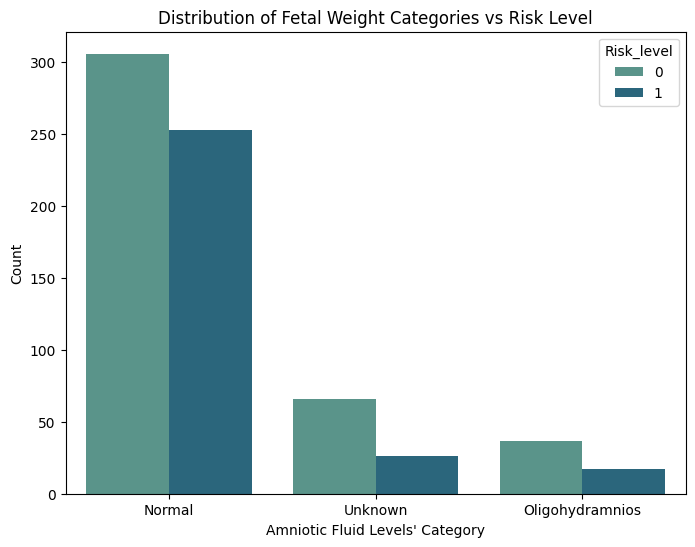

In [681]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="AFI_Category",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of Fetal Weight Categories vs Risk Level")
plt.xlabel("Amniotic Fluid Levels' Category")
plt.ylabel("Count")
plt.show()

In [682]:
pd.crosstab(df["AFI_Category"], df["Risk_level"], normalize="index") * 100

Risk_level,0,1
AFI_Category,,
Normal,54.740608,45.259392
Oligohydramnios,68.518519,31.481481
Unknown,71.739130,28.260870


#### Statistical Association - Chi-Square Test

In [683]:
# Cross-tab
ct = pd.crosstab(df["AFI_Category"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 12.02
Degrees of Freedom: 2
P-value: 2.4535e-03
Cramer's V: 0.131


#### Interpretation 

- No specific pattern is observed 
- Cramer's value is too low to move further with this variable
- discarded for now

“Yes, it’s related, but the relationship is weak enough that including it probably won’t change the model’s decisions much.”

### Binning "Age" and analyzing associated relation with risk

**References**
- https://pmc.ncbi.nlm.nih.gov/articles/PMC4418963/#:~:text=In%20analyses%20that%20controlled%20for,distress%2C%20and%20poor%20fetal%20growth.
- https://pjmhsonline.com/2021/march/873.pdf

In [684]:
df["Age_Group"] = pd.cut(df["Age (yrs)"],
                            bins=[0, 19, 35, 100],
                            labels=["Teenage", "Optimal Age", "Advanced Maternal Age"])

#### Distribution of Age Groups' vs Risk Level 

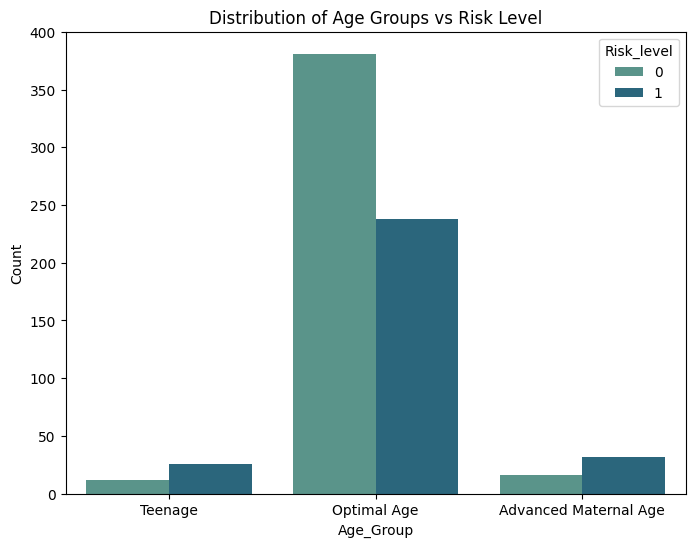

In [685]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="Age_Group",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of Age Groups vs Risk Level")
plt.xlabel("Age_Group")
plt.ylabel("Count")
plt.show()

##### Cross Tab Precentages 

In [686]:
# Crosstab counts
age_crosstab = pd.crosstab(df["Age_Group"], df["Risk_level"])

# Crosstab percentages
age_crosstab_pct = pd.crosstab(df["Age_Group"], df["Risk_level"], normalize="index") * 100

# Combine counts and percentages into one table
age_crosstab_combined = age_crosstab.astype(str) + " (" + age_crosstab_pct.round(1).astype(str) + "%)"

print(age_crosstab_combined)


Risk_level                       0            1
Age_Group                                      
Teenage                 12 (31.6%)   26 (68.4%)
Optimal Age            381 (61.6%)  238 (38.4%)
Advanced Maternal Age   16 (33.3%)   32 (66.7%)


#### Visualization of Relationship 

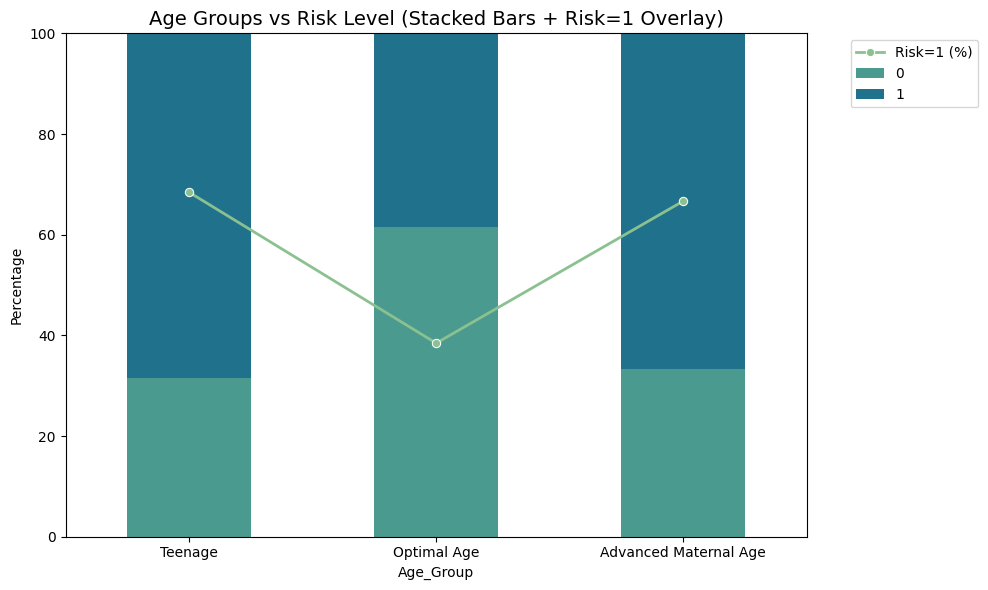

In [687]:
# Percentage cross-tab
age_crosstab_percent = pd.crosstab(
    df["Age_Group"], df["Risk_level"], normalize="index"
) * 100

# Ensure consistent category order
category_order = ["Teenage", "Optimal Age", "Advanced Maternal Age"]
age_crosstab_percent = age_crosstab_percent.reindex(category_order)

# Extract Risk=1 percentages for line
risk1_percent = age_crosstab_percent[1].reset_index()

plt.figure(figsize=(10,6))
colors = ["#4a9a8f", "#20718b"] 
# --- Stacked Bars ---
age_crosstab_percent.plot(
    kind="bar", stacked=True, color=colors, ax=plt.gca()
)

# --- Overlay Line ---
sns.lineplot(
    data=risk1_percent,
    x="Age_Group",
    y=1,
    marker="o",
    color="#8bc191",
    linewidth=2,
    label="Risk=1 (%)"
)

# Formatting
plt.title("Age Groups vs Risk Level (Stacked Bars + Risk=1 Overlay)", fontsize=14)
plt.ylabel("Percentage")
plt.xlabel("Age_Group")
plt.ylim(0, 100)
plt.xticks(rotation=0)  # keep labels aligned
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

#### Statistical Association - Chi-Square Test

In [688]:
# Cross-tab
ct = pd.crosstab(df["Age_Group"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")


Chi-square: 26.08
Degrees of Freedom: 2
P-value: 2.1664e-06
Cramer's V: 0.192


#### Key Interpretations

- U-shaped risk pattern: Both very young (Teenage) ~68% and older mothers (Advanced Maternal Age) ~ 67% show much higher risk levels than the Optimal Age group.
- p-value of ~0.000002 indicates significant relationship between the two categorical features - Age Group and Risk Level
- While Cramer's v provides an overview of relationship strength of 0.2 which implies a small effect size 

### Binning "Gestational Age" and analyzing associated relation with risk

**References**
- https://www.medicalnewstoday.com/articles/323742#second-trimester

In [689]:
df["Trimesters"] = pd.cut(df["gestational age (weeks)"],
                            bins=[0, 12, 28, 40],
                            labels=["First Trimester", "Second Trimester", "Third Trimester"])

#### Distribution of Trimesters vs Risk Level 

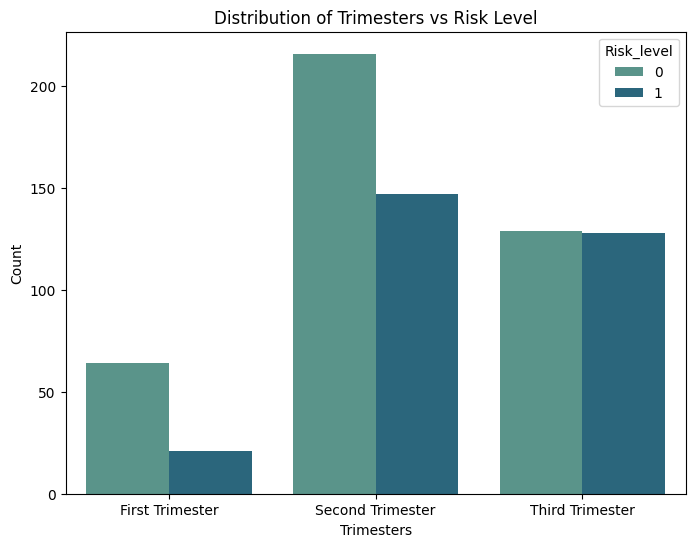

In [690]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="Trimesters",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of Trimesters vs Risk Level")
plt.xlabel("Trimesters")
plt.ylabel("Count")
plt.show()

##### Cross Tab Percentages 

In [691]:
# Crosstab counts
ga_crosstab = pd.crosstab(df["Trimesters"], df["Risk_level"])

# Crosstab percentages
ga_crosstab_pct = pd.crosstab(df["Trimesters"], df["Risk_level"], normalize="index") * 100

# Combine counts and percentages into one table
ga_crosstab_combined = ga_crosstab.astype(str) + " (" + ga_crosstab_pct.round(1).astype(str) + "%)"

print(ga_crosstab_combined)

Risk_level                  0            1
Trimesters                                
First Trimester    64 (75.3%)   21 (24.7%)
Second Trimester  216 (59.5%)  147 (40.5%)
Third Trimester   129 (50.2%)  128 (49.8%)


#### Statistical Association - Chi-Square Test 

In [692]:
# Cross-tab
ct = pd.crosstab(df["Trimesters"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 17.20
Degrees of Freedom: 2
P-value: 1.8388e-04
Cramer's V: 0.156


#### Key Observations

- No significant association of any trimester with high risk 
- Risk of complications rises steadily across pregnancy stages. While trimester alone is not a strong predictor (V=0.156), it’s may have important context — especially in combination with other factors (like MAP, fetal weight, age group, etc.).

### Binning "BMI" and analyzing associated relation with risk level 

In [693]:
df["BMI_Category"] = pd.cut(df["bmi"],
                            bins=[0, 18.4, 24.9, 29.9, 100],
                            labels=["Underweight", "Healthy weight", "Overweight", "Obese"])

#### Distribution of BMI Categories vs Risk Level

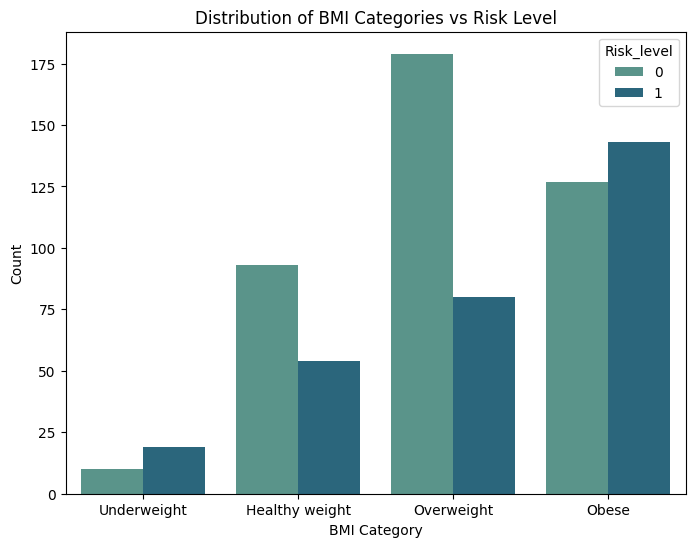

In [694]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="BMI_Category",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of BMI Categories vs Risk Level")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

##### Cross Tab Percentages

In [695]:
# Crosstab counts
bmi_crosstab = pd.crosstab(df["BMI_Category"], df["Risk_level"])

# Crosstab percentages
bmi_crosstab_pct = pd.crosstab(df["BMI_Category"], df["Risk_level"], normalize="index") * 100

# Combine counts and percentages into one table
bmi_crosstab_combined = bmi_crosstab.astype(str) + " (" + bmi_crosstab_pct.round(1).astype(str) + "%)"

print(bmi_crosstab_combined)

Risk_level                0            1
BMI_Category                            
Underweight      10 (34.5%)   19 (65.5%)
Healthy weight   93 (63.3%)   54 (36.7%)
Overweight      179 (69.1%)   80 (30.9%)
Obese           127 (47.0%)  143 (53.0%)


#### Visual Relationship 

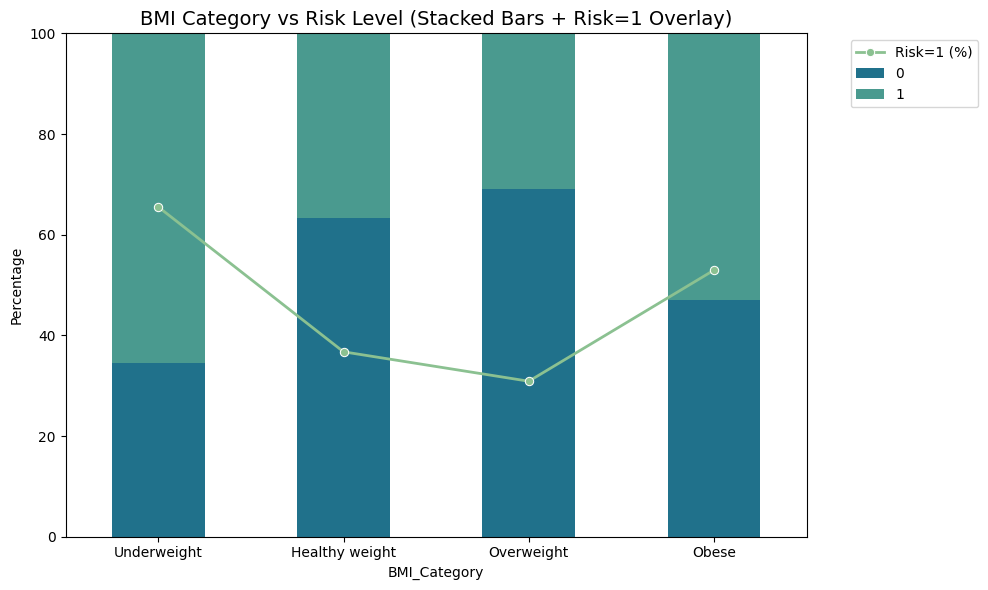

In [696]:


# Ensure consistent category order
category_order = ["Underweight", "Healthy weight", "Overweight", "Obese"]
bmi_crosstab_percent = bmi_crosstab_pct.reindex(category_order)

# Extract Risk=1 percentages for line
risk1_percent = bmi_crosstab_percent[1].reset_index()

plt.figure(figsize=(10,6))
colors = ["#20718b", "#4a9a8f" ] 
# --- Stacked Bars ---
bmi_crosstab_percent.plot(
    kind="bar", stacked=True, color=colors, ax=plt.gca()
)

# --- Overlay Line ---
sns.lineplot(
    data=risk1_percent,
    x="BMI_Category",
    y=1,
    marker="o",
    color="#8bc191",
    linewidth=2,
    label="Risk=1 (%)"
)

# Formatting
plt.title("BMI Category vs Risk Level (Stacked Bars + Risk=1 Overlay)", fontsize=14)
plt.ylabel("Percentage")
plt.xlabel("BMI_Category")
plt.ylim(0, 100)
plt.xticks(rotation=0)  # keep labels aligned
plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

#### Statistical Association - Chi-Square Test 

In [697]:
# Cross-tab
ct = pd.crosstab(df["BMI_Category"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 34.71
Degrees of Freedom: 3
P-value: 1.4031e-07
Cramer's V: 0.222


#### Key Observations

- Risk level is higher across extremes - underweight and obese, thou underweight has a higher association with 65.5%
- U-shaped risk pattern: Both underweight and obese mothers show elevated risk, while healthy weight and especially overweight have lower risk.
- small to moderate assocation as per cramers v



### Binning "HB" per trimesters and analyzing association with risk level  

**References**
- https://pubmed.ncbi.nlm.nih.gov/34623079/#:~:text=Anemia%20is%20defined%20as%20a,guideline%20used)%20is%20considered%20anemia.

In [698]:

# Map thresholds by trimester
hb_thresholds = {
    "First Trimester": 11.0,
    "Second Trimester": 10.5,
    "Third Trimester": 11.0
}

# Create category column
df["Hb_Category"] = df.apply(
    lambda row: "Normal" if row["HB"] >= hb_thresholds[row["Trimesters"]] else "Low",
    axis=1
)


#### Distribution of HB Categories vs Risk Level 

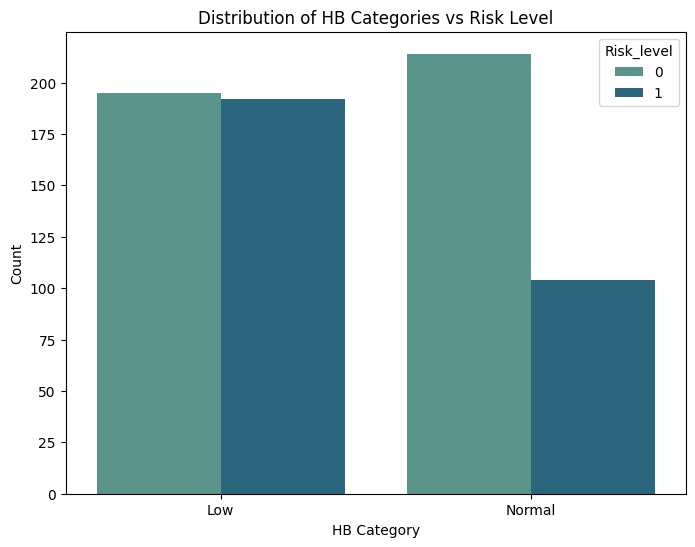

In [699]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x="Hb_Category",
    hue="Risk_level",
    palette="crest"
)
plt.title("Distribution of HB Categories vs Risk Level")
plt.xlabel("HB Category")
plt.ylabel("Count")
plt.show()

##### Cross Tab Percentages 

In [700]:
# Crosstab counts
hb_crosstab = pd.crosstab(df["Hb_Category"], df["Risk_level"])

# Crosstab percentages
hb_crosstab_pct = pd.crosstab(df["Hb_Category"], df["Risk_level"], normalize="index") * 100

# Combine counts and percentages into one table
hb_crosstab_combined = hb_crosstab.astype(str) + " (" + hb_crosstab_pct.round(1).astype(str) + "%)"

print(hb_crosstab_combined)

Risk_level             0            1
Hb_Category                          
Low          195 (50.4%)  192 (49.6%)
Normal       214 (67.3%)  104 (32.7%)


#### Statistical Association - Chi-Square Test

In [701]:
# Cross-tab
ct = pd.crosstab(df["Hb_Category"], df["Risk_level"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print(f"Chi-square: {chi2:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")
print(f"Cramer's V: {cramers_v:.3f}")

Chi-square: 19.80
Degrees of Freedom: 1
P-value: 8.6001e-06
Cramer's V: 0.168


#### Key Observations

- Women with low hemoglobin are much more likely to fall into the high-risk group compared to those with normal Hb.
- Association is statistically significant and clinically relevant, though not extremely strong (V = 0.168).

In [702]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 708
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   gravida                    705 non-null    int64   
 1   parity                     705 non-null    int64   
 2   gestational age (weeks)    705 non-null    float64 
 3   Age (yrs)                  705 non-null    int64   
 4   bmi                        705 non-null    float64 
 5   diabetes                   705 non-null    int64   
 6   History of hypertension    705 non-null    int64   
 7   HB                         705 non-null    float64 
 8   fetal weight(kgs)          705 non-null    float64 
 9   Protien Uria               705 non-null    int64   
 10  amniotic fluid levels(cm)  705 non-null    float64 
 11  Pregnancy_Losses           705 non-null    int64   
 12  MAP                        705 non-null    float64 
 13  MAP_Category               705 non-null 

## Feature Importance 

In [703]:
%pip install dython

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [704]:
df = df[[c for c in df.columns if c != "Risk_level"] + ["Risk_level"]]

In [705]:
df_copy=df.copy()

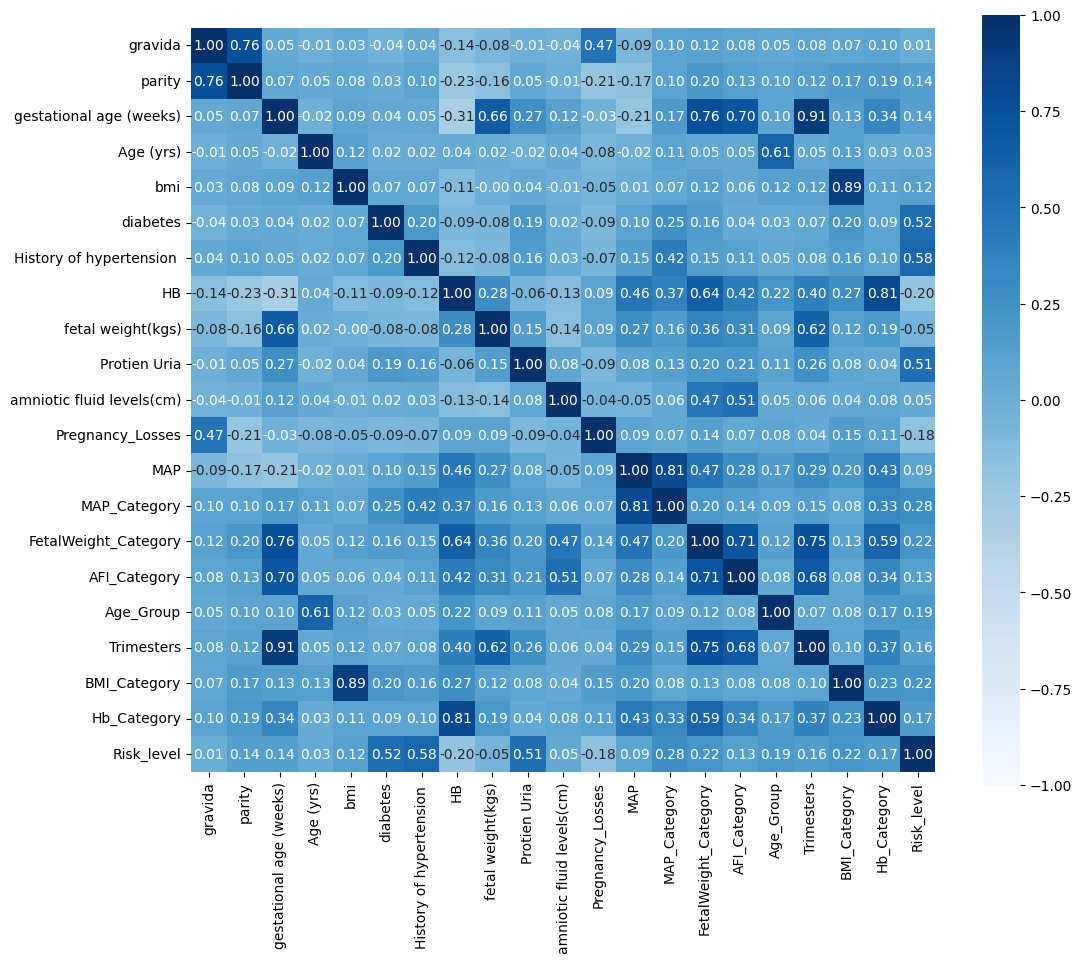

{'corr':                             gravida    parity  gestational age (weeks)  \
 gravida                    1.000000  0.764092                 0.046335   
 parity                     0.764092  1.000000                 0.074355   
 gestational age (weeks)    0.046335  0.074355                 1.000000   
 Age (yrs)                 -0.011398  0.045218                -0.021256   
 bmi                        0.032326  0.075975                 0.092166   
 diabetes                  -0.036311  0.026239                 0.044058   
 History of hypertension    0.041213  0.099491                 0.053787   
 HB                        -0.142965 -0.226629                -0.314573   
 fetal weight(kgs)         -0.084095 -0.156409                 0.664115   
 Protien Uria              -0.012510  0.052112                 0.266979   
 amniotic fluid levels(cm) -0.035919 -0.008498                 0.122390   
 Pregnancy_Losses           0.473785 -0.206092                -0.031219   
 MAP             

In [706]:
from dython.nominal import associations

associations(df, figsize=(12, 10), cmap="Blues", annot=True)

### Removing columns that might cause multi-collinearlity 

In [707]:
df.pop("gravida")

0      4
1      3
2      2
3      3
4      1
      ..
704    3
705    3
706    3
707    3
708    3
Name: gravida, Length: 705, dtype: int64

In [708]:
df.pop("Age (yrs)")
df.pop("bmi")
df.pop("gestational age (weeks)")
df.pop("HB")
df.pop("fetal weight(kgs)")
df.pop("amniotic fluid levels(cm)")
df.pop("MAP")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 708
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   parity                    705 non-null    int64   
 1   diabetes                  705 non-null    int64   
 2   History of hypertension   705 non-null    int64   
 3   Protien Uria              705 non-null    int64   
 4   Pregnancy_Losses          705 non-null    int64   
 5   MAP_Category              705 non-null    category
 6   FetalWeight_Category      705 non-null    object  
 7   AFI_Category              705 non-null    object  
 8   Age_Group                 705 non-null    category
 9   Trimesters                705 non-null    category
 10  BMI_Category              705 non-null    category
 11  Hb_Category               705 non-null    object  
 12  Risk_level                705 non-null    int64   
dtypes: category(4), int64(6), object(3)
memory usage: 58.5+

In [709]:
df = df[[c for c in df.columns if c != "Risk_level"] + ["Risk_level"]]


In [710]:
df.shape

(705, 13)

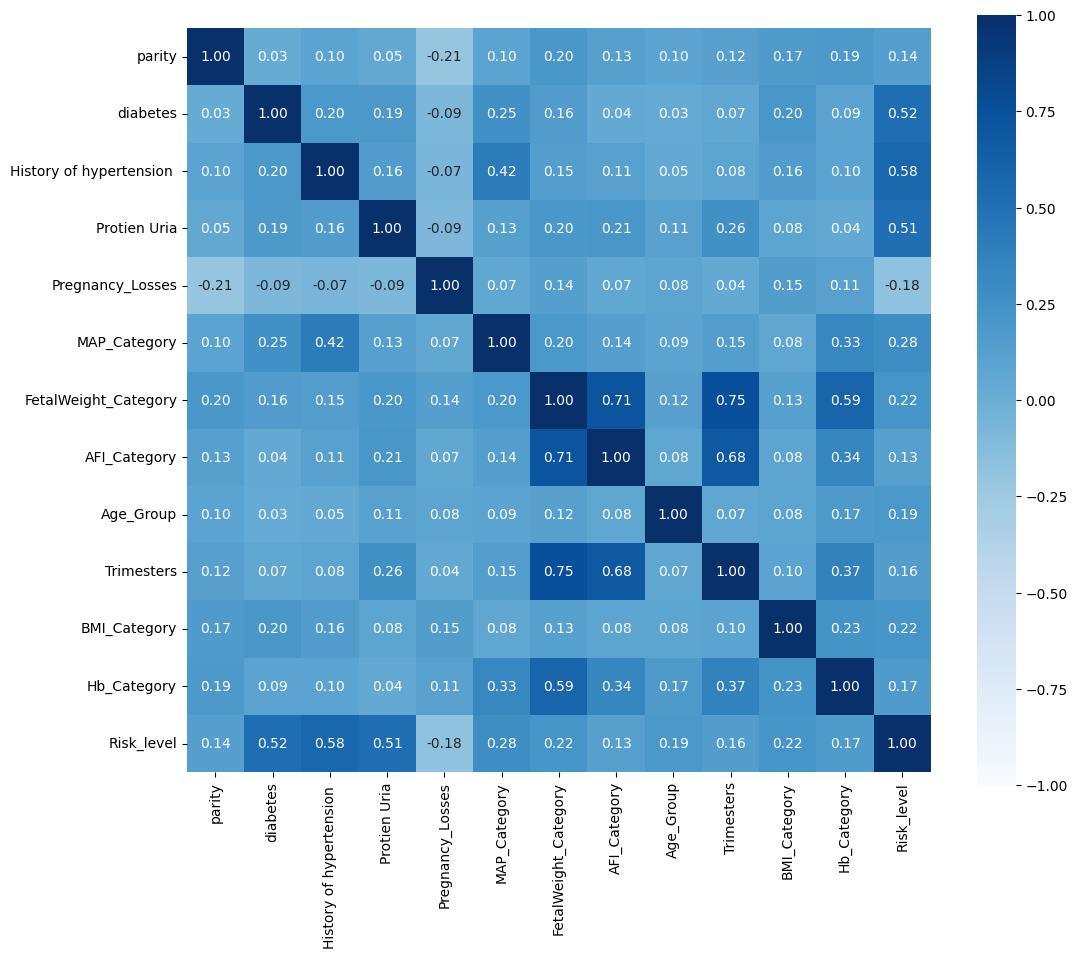

{'corr':                             parity  diabetes  History of hypertension   \
 parity                    1.000000  0.026239                  0.099491   
 diabetes                  0.026239  1.000000                  0.195113   
 History of hypertension   0.099491  0.195113                  1.000000   
 Protien Uria              0.052112  0.186472                  0.156957   
 Pregnancy_Losses         -0.206092 -0.090897                 -0.073302   
 MAP_Category              0.096146  0.253312                  0.418377   
 FetalWeight_Category      0.200822  0.159423                  0.146677   
 AFI_Category              0.131061  0.043855                  0.111408   
 Age_Group                 0.098778  0.031921                  0.046084   
 Trimesters                0.122996  0.070215                  0.081863   
 BMI_Category              0.165292  0.203505                  0.159807   
 Hb_Category               0.187366  0.093956                  0.097121   
 Risk_level      

In [711]:
from dython.nominal import associations

associations(df, figsize=(12, 10), cmap="Blues", annot=True)

## Evaluation of Implications with ML Models 

### Preprocessing - One Hot for Categories and Interactions

In [712]:
# Install required packages for modeling and explanations
%pip install --quiet scikit-learn xgboost shap lime


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [713]:
# Train/test split with preprocessing (one-hot for categoricals)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline


# Use the cleaned/engineered df already in notebook
assert 'df' in globals(), "DataFrame df not found"

# Define feature columns (exclude target). Keep engineered categories and core numeric/binary features
target_col = 'Risk_level'
X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()

# Identify column types present now
categorical_cols = [
    'MAP_Category','FetalWeight_Category','AFI_Category','Age_Group','Trimesters','BMI_Category','Hb_Category'
]
# Some of these may be category dtype; convert to string to keep levels stable
for c in categorical_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)

numeric_cols = [c for c in X.columns if c not in categorical_cols]

# Create interaction features for numeric columns
from sklearn.preprocessing import PolynomialFeatures

# First create interactions for numeric features
numeric_interactions = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler(with_mean=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_interactions, numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop',
    sparse_threshold=0  # Force dense output globally
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Helper to get transformed feature names
# Fit the preprocessor to get feature names
preprocessor.fit(X_train)

# Get polynomial feature names for numeric interactions
poly_transformer = preprocessor.named_transformers_['num'].named_steps['poly']
num_feats = poly_transformer.get_feature_names_out(numeric_cols)

# Get one-hot encoded feature names for categoricals
cat_encoder = preprocessor.named_transformers_['cat']
cat_feats = list(cat_encoder.get_feature_names_out(categorical_cols)) if categorical_cols else []

transformed_feature_names = list(num_feats) + cat_feats

print(f"Total features after interactions: {len(transformed_feature_names)}")
print(f"Original numeric features: {numeric_cols}")
print(f"Polynomial feature names: {list(num_feats)}")
print(f"Categorical feature names: {cat_feats}")  


Total features after interactions: 38
Original numeric features: ['parity', 'diabetes', 'History of hypertension ', 'Protien Uria', 'Pregnancy_Losses']
Polynomial feature names: ['parity', 'diabetes', 'History of hypertension ', 'Protien Uria', 'Pregnancy_Losses', 'parity diabetes', 'parity History of hypertension ', 'parity Protien Uria', 'parity Pregnancy_Losses', 'diabetes History of hypertension ', 'diabetes Protien Uria', 'diabetes Pregnancy_Losses', 'History of hypertension  Protien Uria', 'History of hypertension  Pregnancy_Losses', 'Protien Uria Pregnancy_Losses']
Categorical feature names: ['MAP_Category_Extreme Low', 'MAP_Category_High', 'MAP_Category_Normal', 'MAP_Category_Severe', 'FetalWeight_Category_AGA', 'FetalWeight_Category_LGA', 'FetalWeight_Category_SGA', 'FetalWeight_Category_Unknown', 'AFI_Category_Normal', 'AFI_Category_Oligohydramnios', 'AFI_Category_Unknown', 'Age_Group_Advanced Maternal Age', 'Age_Group_Optimal Age', 'Age_Group_Teenage', 'Trimesters_First Trim

In [714]:
print(f"Original X shape: {X.shape}")        # 705 rows
print(f"X_train shape: {X_train.shape}")    # ~564 rows
print(f"X_test shape: {X_test.shape}")      # ~141 rows

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")

Original X shape: (705, 12)
X_train shape: (564, 12)
X_test shape: (141, 12)
X_train_transformed shape: (564, 38)
X_test_transformed shape: (141, 38)


In [715]:
# Initialize results dictionary for storing model metrics
results = {}

### Logistic Regression 

In [716]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#  Build Random Forest pipeline with overfitting safeguards
lr_clf = Pipeline([
     ('prep', preprocessor),
     ('clf', LogisticRegression(random_state=0, max_iter=1000))
])


# Train and evaluate
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)
y_prob_lr = lr_clf.predict_proba(X_test)[:,1]


# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_lr)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_lr, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_lr, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_lr, pos_label=1)

roc = roc_auc_score(y_test, y_prob_lr)

# Store in dictionary
lr_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)

# Store for later comparison
results['LogisticRegression'] = lr_metrics

print("\n===== Logistic Regression Performance Metrics =====")
for metric, value in lr_metrics.items():
    print(f"{metric:<30}: {value:.3f}")





===== Logistic Regression Performance Metrics =====
Accuracy                      : 0.929
Sensitivity (TPR)             : 0.915
Specificity (TNR)             : 0.939
Precision (Positive Class)    : 0.915
Recall (Positive Class)       : 0.915
F1-Score (Positive Class)     : 0.915
ROC-AUC-Score                 : 0.959


#### Confusion Matrix

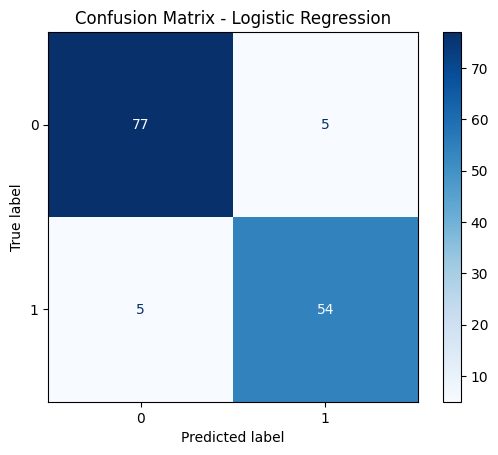

In [717]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### Feature Importance with Logistic Regression 

In [718]:
# Feature importance for Logistic Regression (top coefficients)
lr_coef = lr_clf.named_steps['clf'].coef_[0]
feature_names = transformed_feature_names

# Get top 10 coefficients (absolute value)
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_coef
}).sort_values('coefficient',  ascending=False).head(10)

print("Top 10 Logistic Regression Coefficients:")
print(coef_df)



Top 10 Logistic Regression Coefficients:
                                      feature  coefficient
3                                Protien Uria     1.604211
11                  diabetes Pregnancy_Losses     1.413476
26            Age_Group_Advanced Maternal Age     1.344439
2                    History of hypertension      1.112296
7                         parity Protien Uria     1.070001
13  History of hypertension  Pregnancy_Losses     0.999252
18                        MAP_Category_Severe     0.971030
6             parity History of hypertension      0.739315
1                                    diabetes     0.723605
14              Protien Uria Pregnancy_Losses     0.494849


#### Visualization

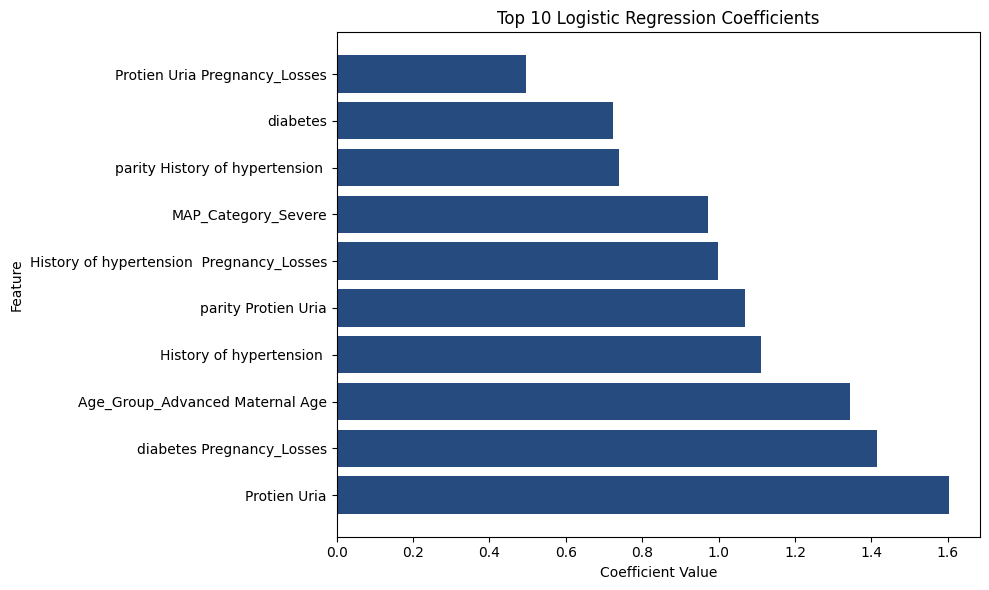

In [719]:
# Bar plot of top coefficients
plt.figure(figsize=(10, 6))
#colors = ['#254b7f' if x < 0 else '#4a9a8f' for x in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color='#254b7f')
plt.title('Top 10 Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Failure Case Analysis - Logistic Regression


In [720]:
# Combine actuals, predictions, and probabilities
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['predicted'] = y_pred_lr
results_df['probability'] = y_prob_lr


In [721]:
# False Positives: predicted 0 but actually 1
false_positives = results_df[(results_df['predicted'] == 1) & (results_df['actual'] == 0)]

# False Negatives: predicted 0 but actually 1
false_negatives = results_df[(results_df['predicted'] == 0) & (results_df['actual'] == 1)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")


False Positives: 5
False Negatives: 5


In [722]:
print("\n=== False Positives (Actual 0, Predicted 1) ===")
display(false_positives.head())

print("\n=== False Negatives (Actual 1, Predicted 0) ===")
display(false_negatives.head())



=== False Positives (Actual 0, Predicted 1) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
602,2,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,0,1,0.801963
685,4,0,0,1,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,0,1,0.989228
349,4,0,0,1,1,Normal,AGA,Normal,Advanced Maternal Age,Third Trimester,Healthy weight,Low,0,1,0.999408
138,2,0,1,0,1,Normal,AGA,Normal,Teenage,Third Trimester,Obese,Normal,0,1,0.925903
71,3,0,1,0,1,Normal,AGA,Normal,Optimal Age,Second Trimester,Overweight,Low,0,1,0.901514



=== False Negatives (Actual 1, Predicted 0) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
449,0,0,0,0,1,Normal,LGA,Oligohydramnios,Optimal Age,Third Trimester,Healthy weight,Normal,1,0,0.029140
517,0,0,0,0,1,Normal,LGA,Normal,Advanced Maternal Age,Second Trimester,Obese,Normal,1,0,0.356331
641,0,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,1,0,0.372498
422,0,0,0,1,4,High,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,1,0,0.343652
475,0,0,0,0,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Healthy weight,Low,1,0,0.018246


##### False Positives' Implications:

- Third Trimester, and Overweight/Obese BMI.
- Over-sensitivity to risk markers like protein uria and hypertension, even when overall context is stable. 

**Pattern:**
Model tends to overpredict risk in patients with slightly abnormal lab features or higher BMI, especially in third trimester

##### False Negatives' Implications

- Mostly Normal MAP, LGA fetal weight, Normal AFI, and Healthy weight/Optimal age
- Model may be underweighting subtle signs of risk—especially when overt medical indicators (such as protien uria, history of hypertension, etc) are absent. Some of these cases might represent latent risks not well captured by the measured variables.

**Pattern:**
High-risk pregnancies(most importantly first pregnancies) with otherwise normal parameters can be missed, suggesting that some interactions need more modeling focus.

### Visual Comparison of Numeric Feature Distribution:

Determine which numeric features differ between failures and correct predictions 

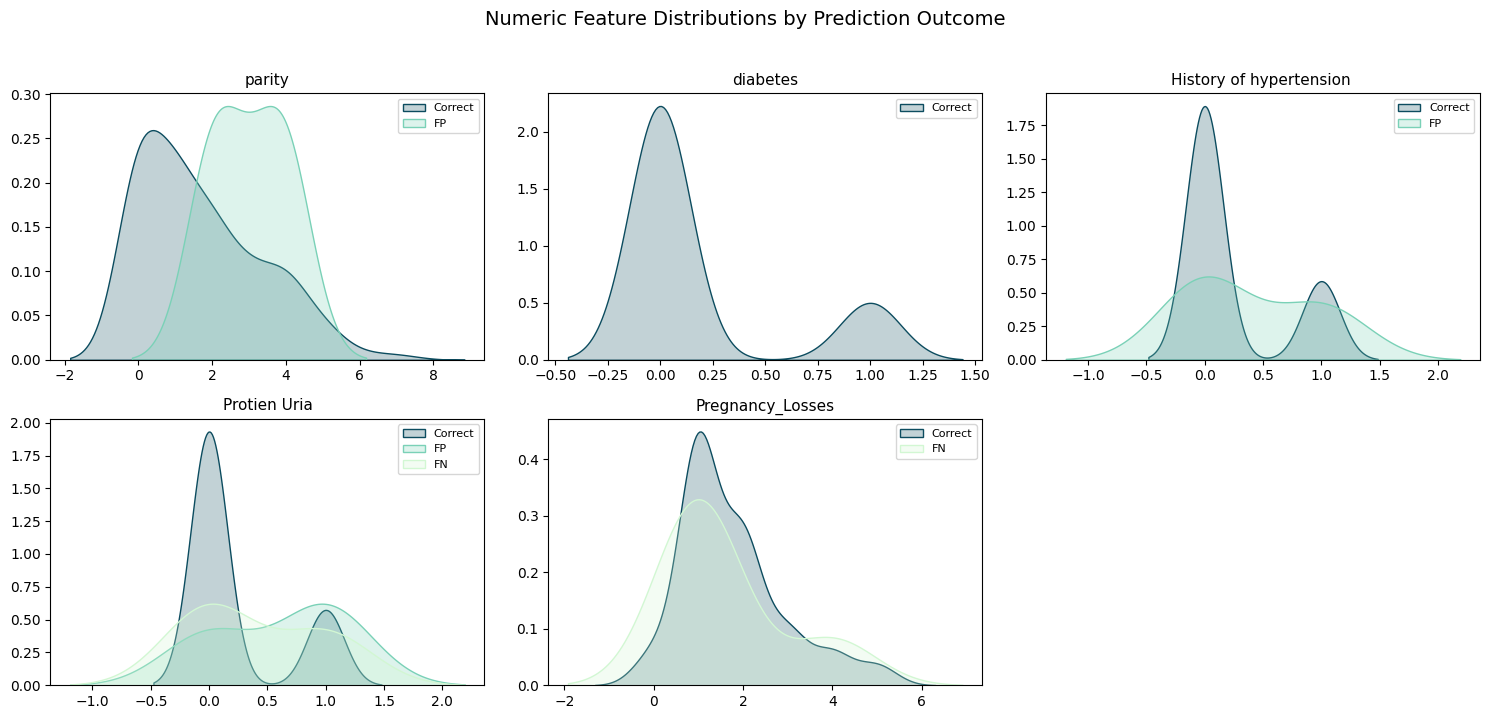

In [723]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Prepare groups
successes = results_df[results_df['actual'] == results_df['predicted']]

# Define colors for clarity
colors = {
    'Correct': '#0C4C5F',
    'FP': '#7AD1B7', 
    'FN': '#D2F7D3'
}

# Number of subplots
num_features = len(numeric_cols)
cols = 3  # you can tweak layout
rows = math.ceil(num_features / cols)

plt.figure(figsize=(5 * cols, 3.5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.kdeplot(successes[col], label='Correct', shade=True, color=colors['Correct'])
        sns.kdeplot(false_positives[col], label='FP', shade=True, color=colors['FP'])
        sns.kdeplot(false_negatives[col], label='FN', shade=True, color=colors['FN'])
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Numeric Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Visual Comparison of Categorical Feature Distribution:

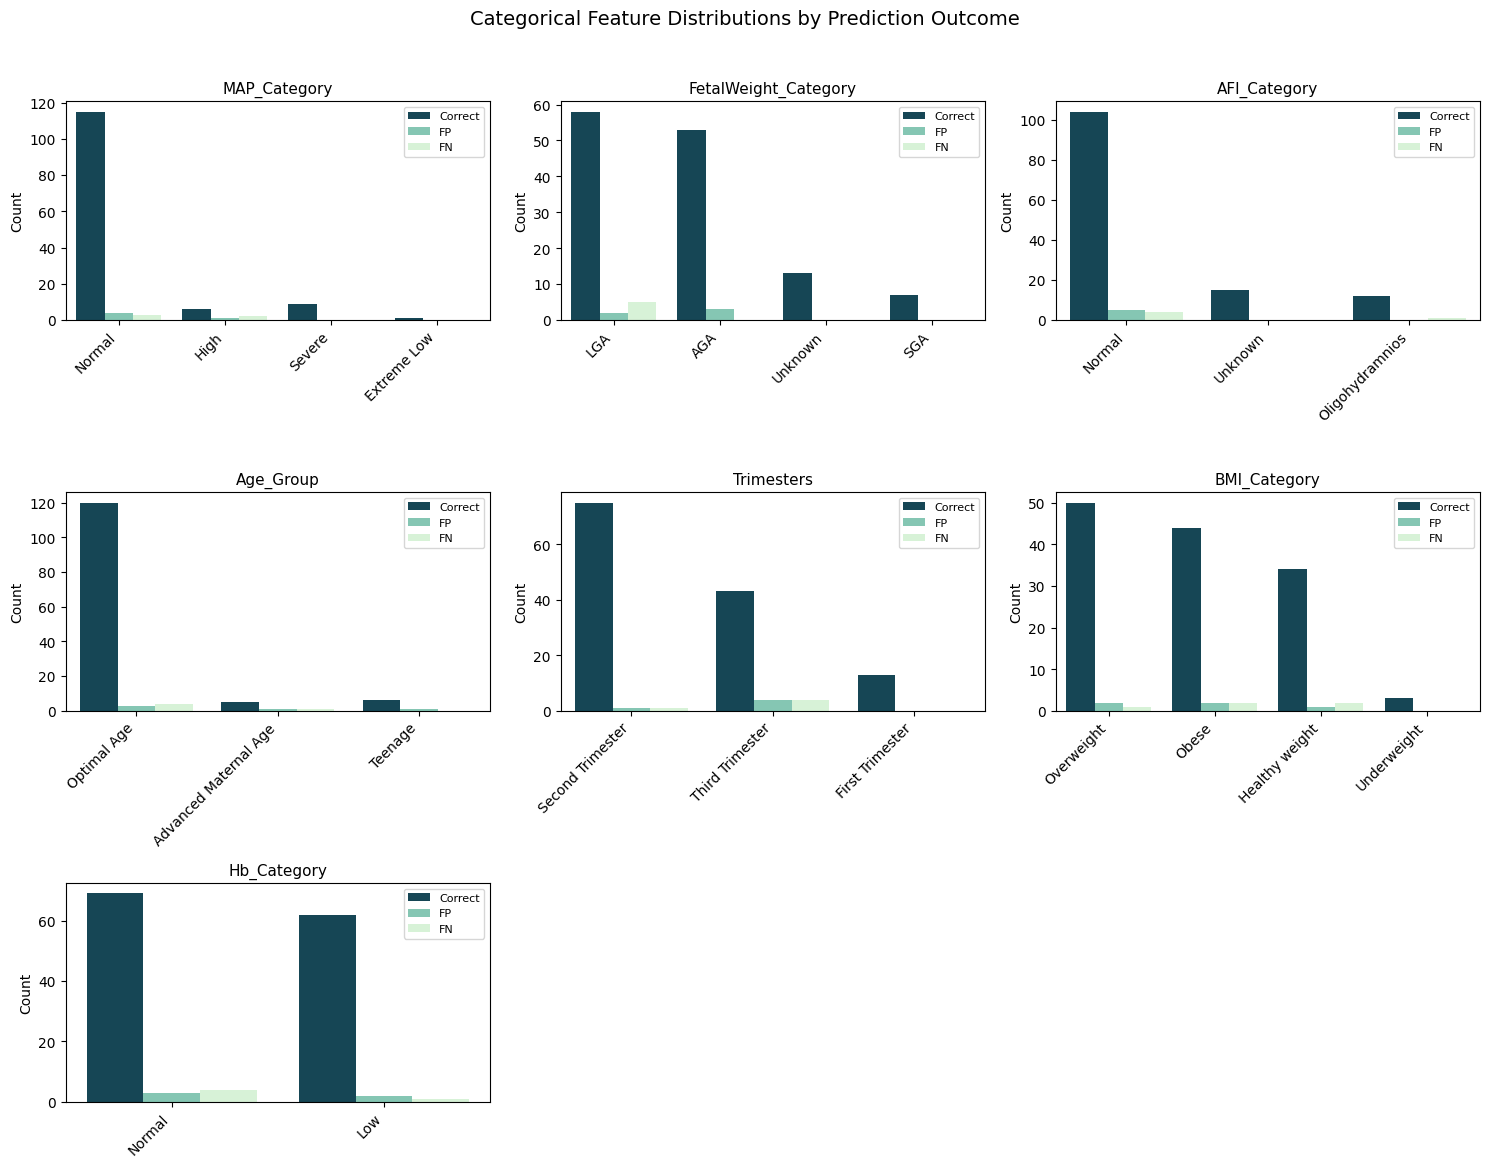

In [724]:
cat_features = [c for c in categorical_cols if c in results_df.columns]
cols = 3
rows = math.ceil(len(cat_features) / cols)

plt.figure(figsize=(5 * cols, 3.8 * rows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    try:
        # Combine group labels for plotting
        temp_df = pd.concat([
            successes.assign(group='Correct'),
            false_positives.assign(group='FP'),
            false_negatives.assign(group='FN')
        ])
        sns.countplot(data=temp_df, x=col, hue='group', 
                      order=temp_df[col].value_counts().index,
                      palette=colors)
        plt.xticks(rotation=45, ha='right')
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Categorical Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Visualization Insights
**Numeric Distributions**
- Proteinuria and hypertension show distinct distribution shifts between correct predictions and false positives, confirming their influence.
- Pregnancy_Losses and Parity distributions overlap slightly, explaining mild confusion in the model’s boundary regions.

**Categorical Distributions**
- Most False Negatives occur in Normal MAP and Normal AFI categories.
- Advanced Maternal Age and Obese BMI categories show higher false positives, aligning with feature importance.

### Random Forest

In [725]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#  Build Random Forest pipeline with overfitting safeguards
rf_clf = Pipeline([
     ('prep', preprocessor),
     ('clf', RandomForestClassifier(
        n_estimators=200,       # more trees for stability
        max_depth=None,            # limit depth
        min_samples_split=4,    # minimum samples to split
        min_samples_leaf=2,     # minimum samples per leaf
        max_features='sqrt', 
        bootstrap=True,
        random_state=42 ))
])

#Cross-Validation (5-Fold)
# ------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Cross-Validation Accuracy (Mean ± Std): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Train and evaluate
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:,1]


# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_rf)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_rf, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_rf, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_rf, pos_label=1)

roc = roc_auc_score(y_test, y_prob_rf)

# Store in dictionary
rf_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)


# Store for later comparison
results['RandomForest'] = rf_metrics

print("\n===== Random Forest Performance Metrics =====")
for metric, value in rf_metrics.items():
    print(f"{metric:<30}: {value:.3f}")




Cross-Validation Accuracy (Mean ± Std): 0.940 ± 0.012

===== Random Forest Performance Metrics =====
Accuracy                      : 0.929
Sensitivity (TPR)             : 0.932
Specificity (TNR)             : 0.927
Precision (Positive Class)    : 0.902
Recall (Positive Class)       : 0.932
F1-Score (Positive Class)     : 0.917
ROC-AUC-Score                 : 0.971


#### Confusion Matrix 

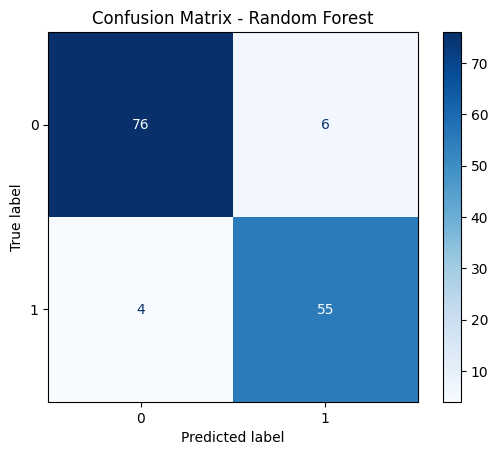

In [726]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

#### Feature Importance with Random Forest

In [727]:
# Feature importance for Random Forest (top feature importances)
rf_importance = rf_clf.named_steps['clf'].feature_importances_
feature_names = transformed_feature_names

# Get top 10 feature importances
rf_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance
}).sort_values('importance', ascending=False).head(20)

print("Top 20 Random Forest Feature Importances:")
print(rf_imp_df)


Top 20 Random Forest Feature Importances:
                                      feature  importance
2                    History of hypertension     0.143220
11                  diabetes Pregnancy_Losses    0.109935
13  History of hypertension  Pregnancy_Losses    0.106392
1                                    diabetes    0.101488
3                                Protien Uria    0.100798
14              Protien Uria Pregnancy_Losses    0.091373
6             parity History of hypertension     0.059569
7                         parity Protien Uria    0.050613
5                             parity diabetes    0.033536
0                                      parity    0.024525
4                            Pregnancy_Losses    0.020158
8                     parity Pregnancy_Losses    0.014903
27                      Age_Group_Optimal Age    0.014053
26            Age_Group_Advanced Maternal Age    0.010783
37                         Hb_Category_Normal    0.010128
12      History of hypertensio

#### Visualization

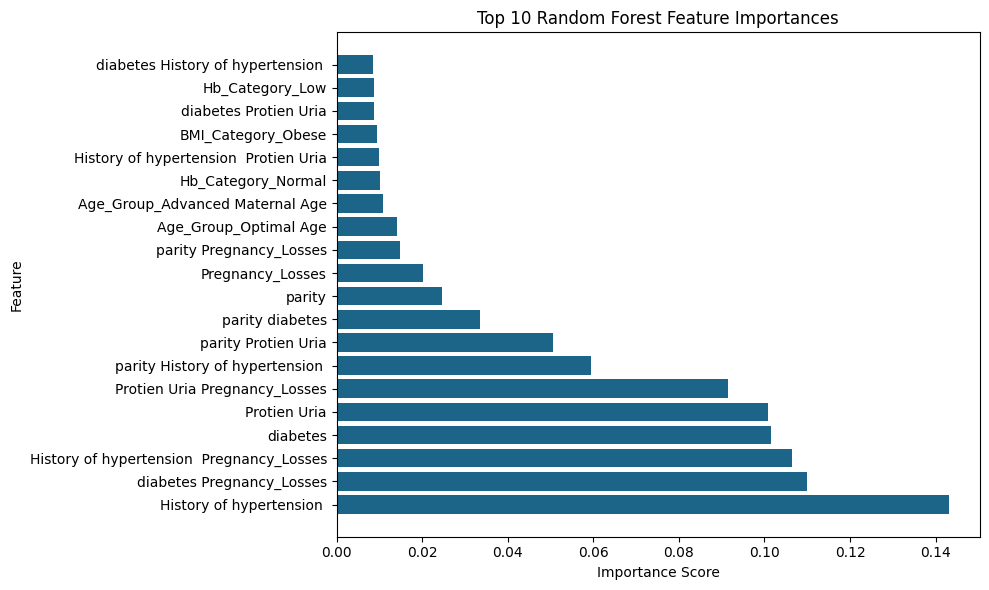

In [728]:
# Bar plot of top importances
plt.figure(figsize=(10, 6))
plt.barh(rf_imp_df['feature'], rf_imp_df['importance'], color='#1c6488')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Failure Case Analysis - Random Forest

In [729]:
# Combine actuals, predictions, and probabilities
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['predicted'] = y_pred_rf
results_df['probability'] = y_prob_rf

In [730]:
# False Positives: predicted 1 but actually 0
false_positives = results_df[(results_df['predicted'] == 1) & (results_df['actual'] == 0)]

# False Negatives: predicted 0 but actually 1
false_negatives = results_df[(results_df['predicted'] == 0) & (results_df['actual'] == 1)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

False Positives: 6
False Negatives: 4


In [731]:
print("\n=== False Positives (Predicted 1, Actually 0) ===")
display(false_positives.head())

print("\n=== False Negatives (Predicted 0, Actually 1) ===")
display(false_negatives.head(6))



=== False Positives (Predicted 1, Actually 0) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
659,0,0,0,1,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,0,1,0.520066
602,2,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,0,1,0.806185
685,4,0,0,1,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,0,1,0.835824
349,4,0,0,1,1,Normal,AGA,Normal,Advanced Maternal Age,Third Trimester,Healthy weight,Low,0,1,0.894256
138,2,0,1,0,1,Normal,AGA,Normal,Teenage,Third Trimester,Obese,Normal,0,1,0.833881



=== False Negatives (Predicted 0, Actually 1) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
449,0,0,0,0,1,Normal,LGA,Oligohydramnios,Optimal Age,Third Trimester,Healthy weight,Normal,1,0,0.071707
641,0,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,1,0,0.447798
422,0,0,0,1,4,High,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,1,0,0.319476
475,0,0,0,0,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Healthy weight,Low,1,0,0.056236


##### False Positives' Implications

- Frequent parity ≥ 2 and Pregnancy_Losses = 1.
- The Random Forest’s high weighting on interaction terms such as “History of Hypertension × Pregnancy_Losses” (0.1116) and “Protien Uria × Pregnancy_Losses” (0.0862) may have caused over-sensitivity. Even mild or isolated pregnancy loss, when paired with elevated parity, likely led to risk overestimation.
- Several false positives also appear in the Third Trimester and LGA (Large for Gestational Age) fetal weight category — both of which the model may interpret as red flags due to their subtle association with complications in the training data.
- The high predicted probabilities (0.75–0.95) indicate strong confidence in incorrect classifications, suggesting that these feature combinations strongly activate multiple decision trees — a sign of feature interaction bias rather than random error.

##### False Negatives' Implications

- Several FN cases had normal Protien Uria and Hb levels, no hypertension history, and belonged to the Optimal Age group, yet were actually positive.
- **Over-reliance on top features:**
Since the top features revolve around hypertension, diabetes, and proteinuria, patients lacking these “strong” risk markers were likely underweighted by the model, leading to missed predictions.
- **Model behavior insight:**
Probability scores for false negatives (0.03–0.50) are notably lower than false positives, confirming the model’s cautious bias toward negative classification when strong risk indicators are absent.

### Visual Comparison of Numeric Feature Distribution:

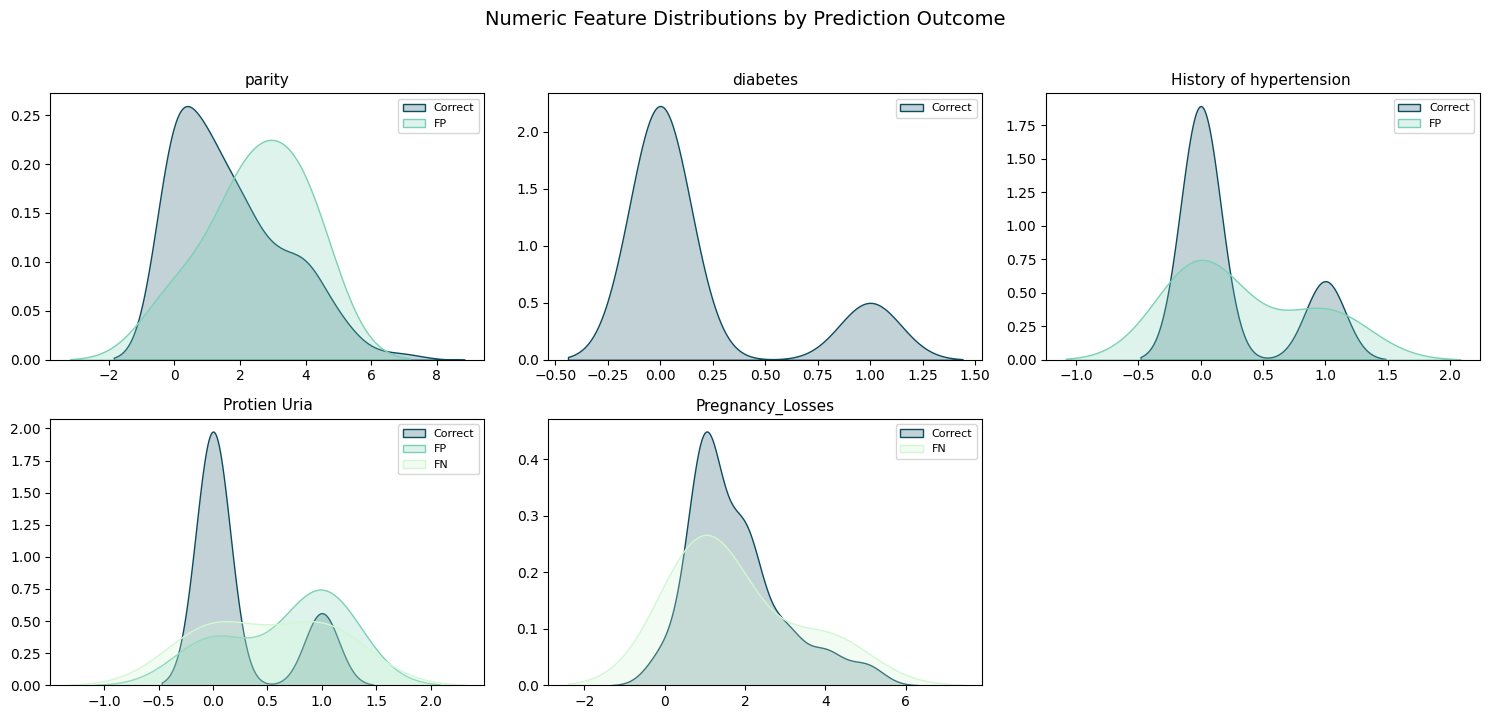

In [732]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Prepare groups
successes = results_df[results_df['actual'] == results_df['predicted']]

# Define colors for clarity
colors = {
    'Correct': '#0C4C5F',
    'FP': '#7AD1B7', 
    'FN': '#D2F7D3'
}

# Number of subplots
num_features = len(numeric_cols)
cols = 3  # you can tweak layout
rows = math.ceil(num_features / cols)

plt.figure(figsize=(5 * cols, 3.5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.kdeplot(successes[col], label='Correct', shade=True, color=colors['Correct'])
        sns.kdeplot(false_positives[col], label='FP', shade=True, color=colors['FP'])
        sns.kdeplot(false_negatives[col], label='FN', shade=True, color=colors['FN'])
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Numeric Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Visual Comparison of Categorical Feature Distribution:

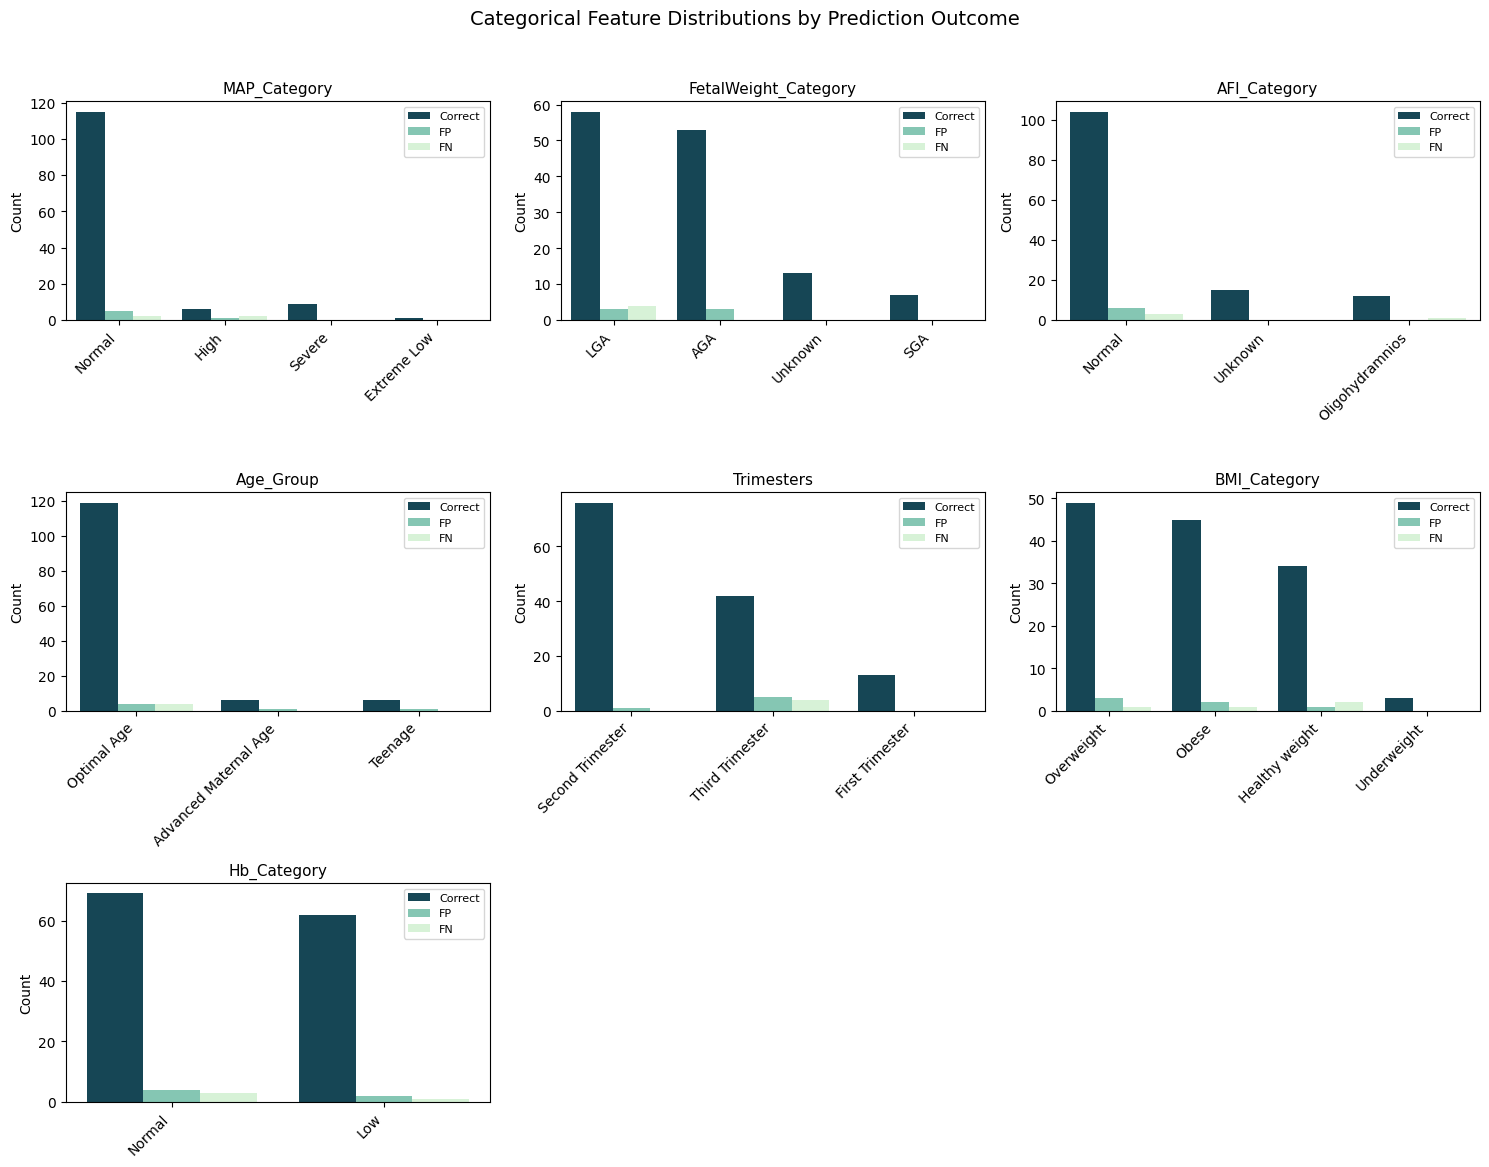

In [733]:
cat_features = [c for c in categorical_cols if c in results_df.columns]
cols = 3
rows = math.ceil(len(cat_features) / cols)

plt.figure(figsize=(5 * cols, 3.8 * rows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    try:
        # Combine group labels for plotting
        temp_df = pd.concat([
            successes.assign(group='Correct'),
            false_positives.assign(group='FP'),
            false_negatives.assign(group='FN')
        ])
        sns.countplot(data=temp_df, x=col, hue='group', 
                      order=temp_df[col].value_counts().index,
                      palette=colors)
        plt.xticks(rotation=45, ha='right')
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Categorical Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### XGB 

In [734]:
# Train XGBoost
from xgboost import XGBClassifier

# Build XGBoost pipeline
xgb_clf = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'))
])


# Train and evaluate
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]



# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_xgb)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_xgb, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_xgb, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_xgb, pos_label=1)

roc = roc_auc_score(y_test, y_prob_xgb)

# Store in dictionary
xgb_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)

# Store for later comparison
results['XGB'] = xgb_metrics

print("\n===== XGB Performance Metrics =====")
for metric, value in xgb_metrics.items():
    print(f"{metric:<30}: {value:.3f}")







===== XGB Performance Metrics =====
Accuracy                      : 0.901
Sensitivity (TPR)             : 0.864
Specificity (TNR)             : 0.927
Precision (Positive Class)    : 0.895
Recall (Positive Class)       : 0.864
F1-Score (Positive Class)     : 0.879
ROC-AUC-Score                 : 0.965


#### Confusion Matrix 

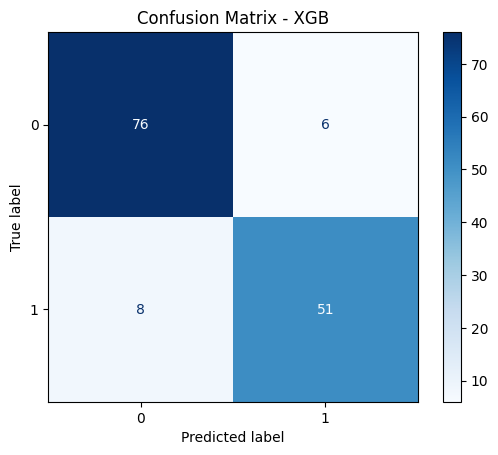

In [735]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGB")
plt.show()

#### Feature Importance with XGB

In [736]:
# Feature importance for XGBoost (top feature importances)
xgb_importance = xgb_clf.named_steps['clf'].feature_importances_
feature_names = transformed_feature_names

# Get top 10 feature importances
xgb_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_importance
}).sort_values('importance', ascending=False).head(10)

print("Top 10 XGBoost Feature Importances:")
print(xgb_imp_df)


Top 10 XGBoost Feature Importances:
                                      feature  importance
2                    History of hypertension     0.124817
1                                    diabetes    0.121015
3                                Protien Uria    0.093768
14              Protien Uria Pregnancy_Losses    0.089163
13  History of hypertension  Pregnancy_Losses    0.080364
7                         parity Protien Uria    0.055770
18                        MAP_Category_Severe    0.050011
11                  diabetes Pregnancy_Losses    0.045808
27                      Age_Group_Optimal Age    0.029943
9           diabetes History of hypertension     0.029815


#### Visualization

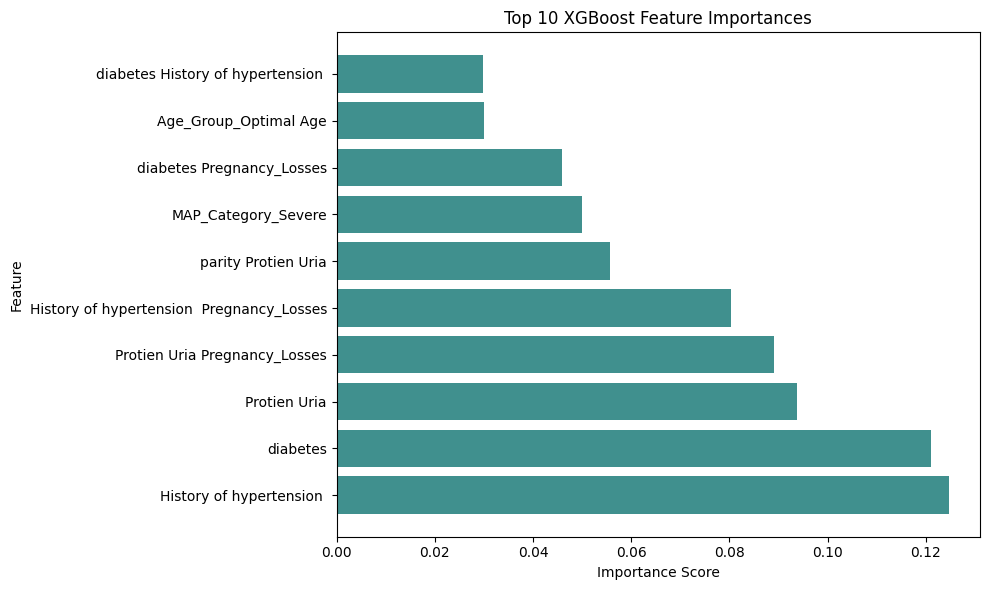

In [737]:
# Bar plot of top importances
plt.figure(figsize=(10, 6))
plt.barh(xgb_imp_df['feature'], xgb_imp_df['importance'], color='#40908e')
plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Failure Analysis - XGB 

In [738]:
# Combine actuals, predictions, and probabilities
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['predicted'] = y_pred_xgb
results_df['probability'] = y_prob_xgb

In [739]:
# False Positives: predicted 1 but actually 0
false_positives = results_df[(results_df['predicted'] == 1) & (results_df['actual'] == 0)]

# False Negatives: predicted 0 but actually 1
false_negatives = results_df[(results_df['predicted'] == 0) & (results_df['actual'] == 1)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

False Positives: 6
False Negatives: 8


In [740]:
print("\n=== False Positives (Predicted 1, Actually 0) ===")
display(false_positives.head(6))

print("\n=== False Negatives (Predicted 0, Actually 1) ===")
display(false_negatives.head(8))



=== False Positives (Predicted 1, Actually 0) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
569,0,0,0,1,2,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,0,1,0.504633
602,2,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,0,1,0.884917
685,4,0,0,1,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,0,1,0.953697
349,4,0,0,1,1,Normal,AGA,Normal,Advanced Maternal Age,Third Trimester,Healthy weight,Low,0,1,0.998920
138,2,0,1,0,1,Normal,AGA,Normal,Teenage,Third Trimester,Obese,Normal,0,1,0.963522
71,3,0,1,0,1,Normal,AGA,Normal,Optimal Age,Second Trimester,Overweight,Low,0,1,0.958094



=== False Negatives (Predicted 0, Actually 1) ===


,parity,diabetes,History of hypertension,Protien Uria,Pregnancy_Losses,MAP_Category,FetalWeight_Category,AFI_Category,Age_Group,Trimesters,BMI_Category,Hb_Category,actual,predicted,probability
162,0,0,1,0,3,Normal,AGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,1,0,0.307521
214,1,1,0,0,2,Normal,AGA,Normal,Optimal Age,Second Trimester,Overweight,Normal,1,0,0.499854
449,0,0,0,0,1,Normal,LGA,Oligohydramnios,Optimal Age,Third Trimester,Healthy weight,Normal,1,0,0.002507
249,3,0,1,0,3,Normal,LGA,Normal,Optimal Age,Second Trimester,Healthy weight,Normal,1,0,0.089803
641,0,0,0,1,1,High,LGA,Normal,Optimal Age,Third Trimester,Overweight,Normal,1,0,0.139461
422,0,0,0,1,4,High,LGA,Normal,Optimal Age,Third Trimester,Obese,Normal,1,0,0.192408
59,2,0,1,0,3,Normal,AGA,Normal,Optimal Age,Third Trimester,Obese,Low,1,0,0.192880
475,0,0,0,0,1,Normal,LGA,Normal,Optimal Age,Third Trimester,Healthy weight,Low,1,0,0.001025


##### False Positives' Implications

- Clearly all false positives share third trimester, High or Normal MAP, and LGA fetuses, alongside Pregnancy_Losses ≥ 1. These conditions collectively form a risk-like profile that the model over-penalizes.
- **Feature influence:**
Top drivers such as History of Hypertension (0.154), Diabetes (0.127), and their interactions with Pregnancy_Losses (0.126) clearly dominate these outcomes.
- **Confidence distribution:**
False positives register very high probabilities (0.50–0.99) — much like Gradient Boosting — reflecting overconfidence in recurrent feature pairings even without complete clinical evidence.

##### False Negatives' Implications:

- These patients generally present Normal MAP, Optimal Age, and Third Trimester, i.e., medically stable-looking profiles that XGBoost treats as low risk.
- False negatives display low-to-mid confidence (0.00–0.46), implying that the model remains cautious about borderline low-signal samples rather than misfiring aggressively.

### Visual Comparison of Numerical Feature Distribution:

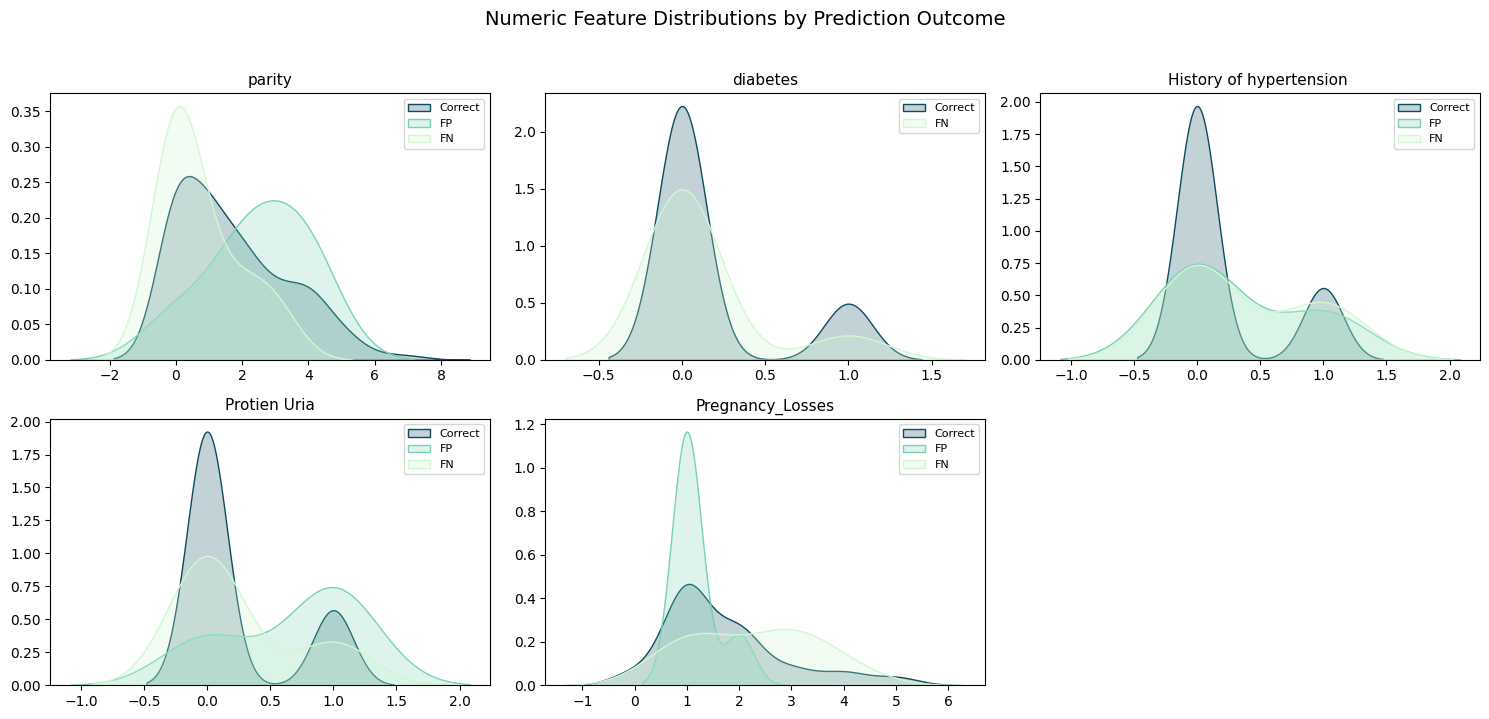

In [741]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Prepare groups
successes = results_df[results_df['actual'] == results_df['predicted']]

# Define colors for clarity
colors = {
    'Correct': '#0C4C5F',
    'FP': '#7AD1B7', 
    'FN': '#D2F7D3'
}

# Number of subplots
num_features = len(numeric_cols)
cols = 3  # you can tweak layout
rows = math.ceil(num_features / cols)

plt.figure(figsize=(5 * cols, 3.5 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.kdeplot(successes[col], label='Correct', shade=True, color=colors['Correct'])
        sns.kdeplot(false_positives[col], label='FP', shade=True, color=colors['FP'])
        sns.kdeplot(false_negatives[col], label='FN', shade=True, color=colors['FN'])
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Numeric Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Visual Comparison of Categorical Feature Distribution:

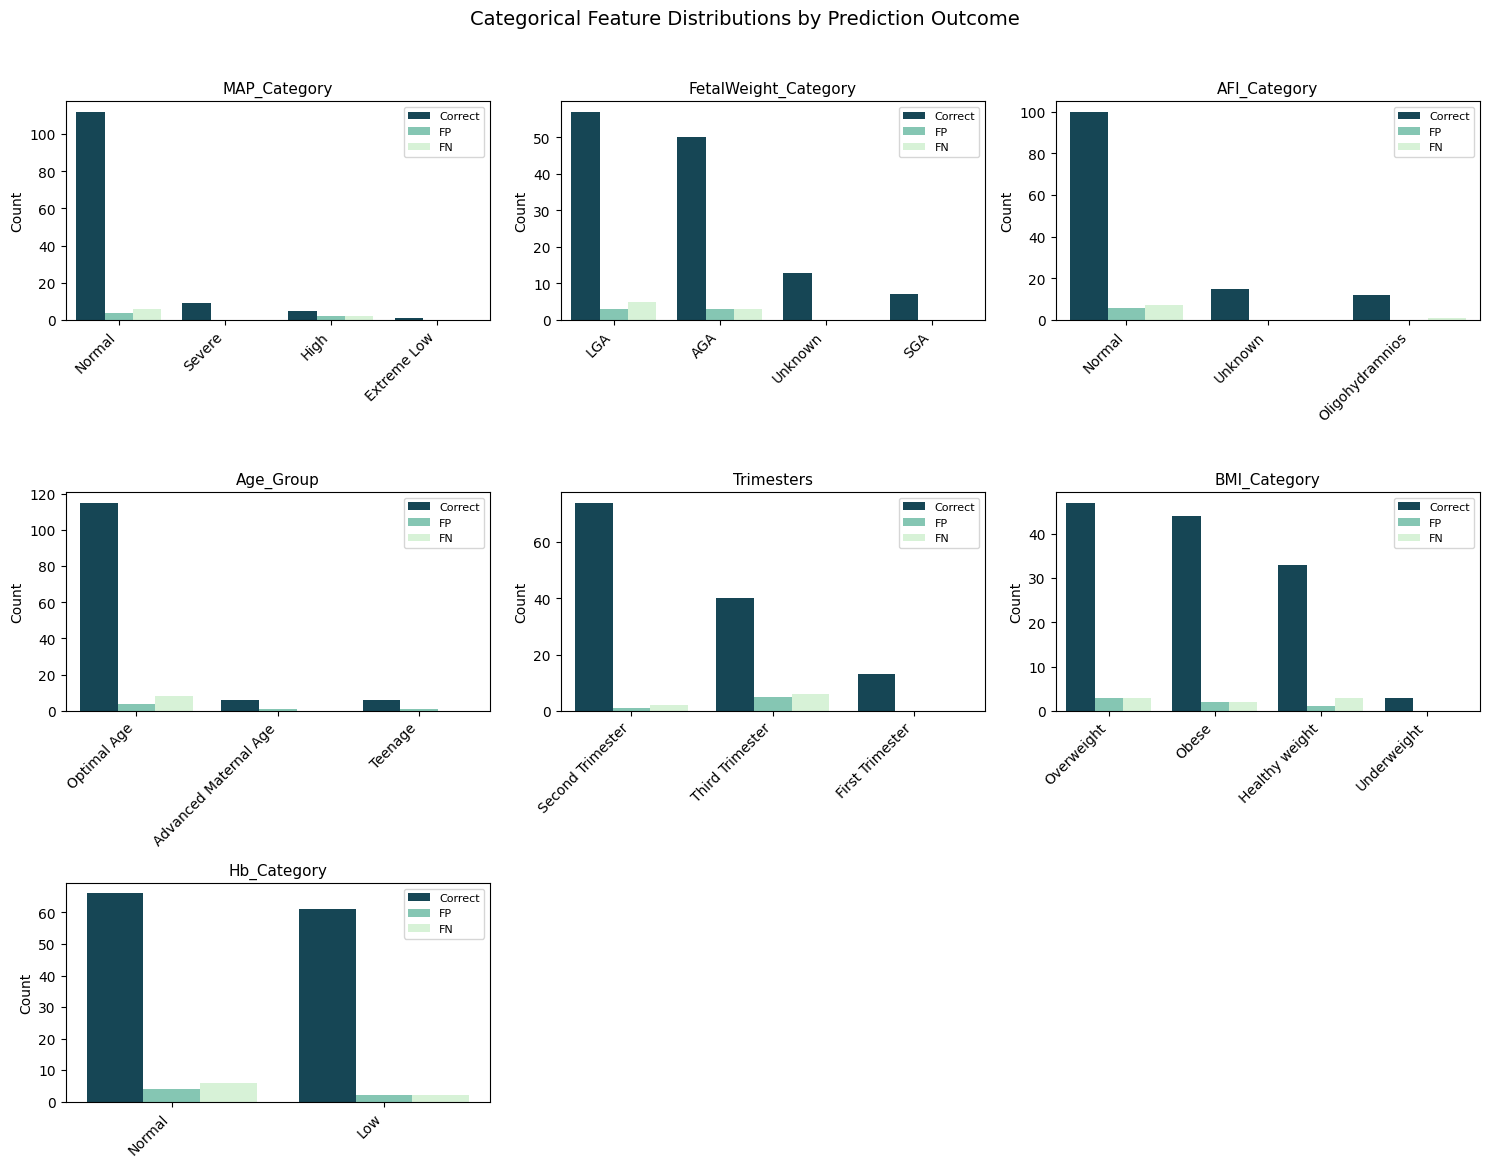

In [742]:
cat_features = [c for c in categorical_cols if c in results_df.columns]
cols = 3
rows = math.ceil(len(cat_features) / cols)

plt.figure(figsize=(5 * cols, 3.8 * rows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(rows, cols, i)
    try:
        # Combine group labels for plotting
        temp_df = pd.concat([
            successes.assign(group='Correct'),
            false_positives.assign(group='FP'),
            false_negatives.assign(group='FN')
        ])
        sns.countplot(data=temp_df, x=col, hue='group', 
                      order=temp_df[col].value_counts().index,
                      palette=colors)
        plt.xticks(rotation=45, ha='right')
    except Exception as e:
        print(f"Skipping {col}: {e}")
        continue

    plt.title(col, fontsize=11)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.legend(fontsize=8)
    plt.tight_layout()

plt.suptitle("Categorical Feature Distributions by Prediction Outcome", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### LightGBM

In [743]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [744]:
%pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [745]:

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline  

# Transform training data through preprocessor
# X_train_trans = preprocessor.transform(X_train)
# X_test_trans = preprocessor.transform(X_test)

# #  Handle Class Imbalance
# print("\nClass distribution before SMOTE:", Counter(y_train))
# smote = SMOTE(random_state=42, k_neighbors=3)
# X_train_res, y_train_res = smote.fit_resample(X_train_trans, y_train)
# print("Class distribution after SMOTE:", Counter(y_train_res))

# # Scale Features
# scaler = StandardScaler()
# X_train_res_scaled = scaler.fit_transform(X_train_res)
# X_test_scaled = scaler.transform(X_test)

# Build Light GBM pipeline
# SMOTE inside pipeline (applied after preprocessing)
#('smote', SMOTE(random_state=42, k_neighbors=3)),
lgb_clf = ImbPipeline([
    ('preprocessor', preprocessor),  # numeric interactions + one-hot
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        num_leaves=10,
        min_child_samples=30,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        min_split_gain=0.1
    ))
])


# Train and evaluate
lgb_clf.fit(X_train, y_train)

y_pred_lgb = lgb_clf.predict(X_test)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:,1]


# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lgb).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_lgb)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_lgb, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_lgb, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_lgb, pos_label=1)

roc = roc_auc_score(y_test, y_prob_lgb)

# Store in dictionary
lgb_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)

# Store for later comparison
results['LightGBM'] = lgb_metrics

print("\n===== Light GBM Performance Metrics =====")
for metric, value in lgb_metrics.items():
    print(f"{metric:<30}: {value:.3f}")


#  Cross-Validation (for reliability)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lgb_clf, X, y, cv=cv, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")




[LightGBM] [Info] Number of positive: 327, number of negative: 327
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024924 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 232
[LightGBM] [Info] Number of data points in the train set: 654, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [746]:
print("\n===== Light GBM Performance Metrics =====")
for metric, value in lgb_metrics.items():
    print(f"{metric:<30}: {value:.3f}")
    


===== Light GBM Performance Metrics =====
Accuracy                      : 0.929
Sensitivity (TPR)             : 0.949
Specificity (TNR)             : 0.915
Precision (Positive Class)    : 0.889
Recall (Positive Class)       : 0.949
F1-Score (Positive Class)     : 0.918
ROC-AUC-Score                 : 0.965


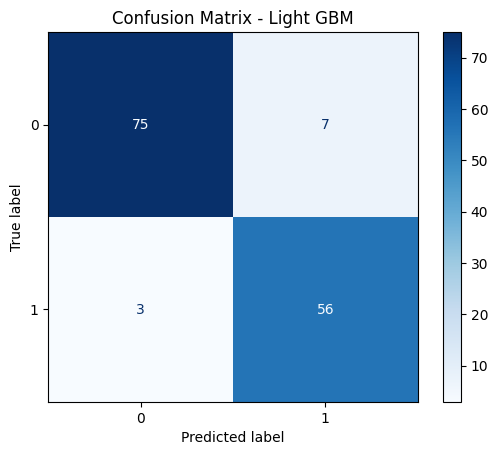

In [747]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lgb_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Light GBM")
plt.show()

### SVM

In [748]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

# Build SVM pipeline
svm_clf = Pipeline([
    ('prep', preprocessor),
    ('clf', SVC(
        kernel='rbf', 
        C=1.0, 
        gamma='scale', 
        probability=True, 
        random_state=42))
])


# Train and evaluate
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)
y_prob_svm = svm_clf.predict_proba(X_test)[:,1]



# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_svm)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_svm, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_svm, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_svm, pos_label=1)

roc = roc_auc_score(y_test, y_prob_svm)

# Store in dictionary
svm_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)


#  Cross-Validation (for reliability)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_clf, X, y, cv=cv, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Store for later comparison
results['SVM'] = svm_metrics

print("\n===== SVM Performance Metrics =====")
for metric, value in svm_metrics.items():
    print(f"{metric:<30}: {value:.3f}")
    
    
    
    





Cross-Validation Accuracy: 0.925 ± 0.017

===== SVM Performance Metrics =====
Accuracy                      : 0.915
Sensitivity (TPR)             : 0.915
Specificity (TNR)             : 0.915
Precision (Positive Class)    : 0.885
Recall (Positive Class)       : 0.915
F1-Score (Positive Class)     : 0.900
ROC-AUC-Score                 : 0.954


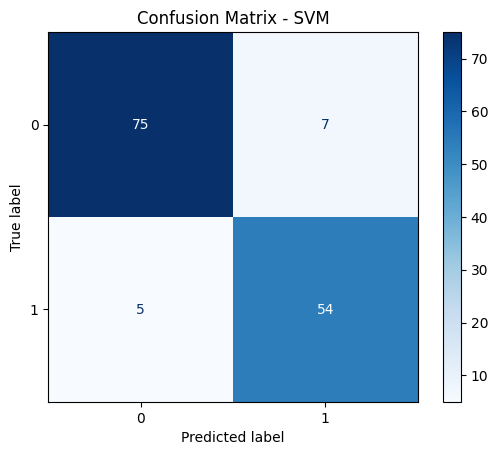

In [749]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

### KNN

In [750]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)


# Build KNN pipeline
knn_clf = Pipeline([
    ('prep', preprocessor),
    ('clf', KNeighborsClassifier(
        n_neighbors=5,          # Default: 5 neighbors
        metric='minkowski',     # Euclidean distance
        p=2 ))
])


# Train and evaluate
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)
y_prob_knn = knn_clf.predict_proba(X_test)[:,1]



# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_knn)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_knn, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_knn, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_knn, pos_label=1)

roc = roc_auc_score(y_test, y_prob_knn)

# Store in dictionary
knn_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)

# Store for later comparison
results['KNN'] = knn_metrics

print("\n===== KNN Performance Metrics =====")
for metric, value in knn_metrics.items():
    print(f"{metric:<30}: {value:.3f}")





===== KNN Performance Metrics =====
Accuracy                      : 0.915
Sensitivity (TPR)             : 0.881
Specificity (TNR)             : 0.939
Precision (Positive Class)    : 0.912
Recall (Positive Class)       : 0.881
F1-Score (Positive Class)     : 0.897
ROC-AUC-Score                 : 0.951


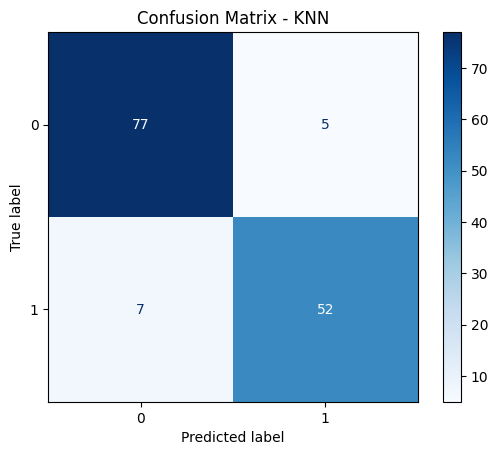

In [751]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.show()

### Decision Tree 

In [752]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)


# Build Decision Tree pipeline
dt_clf = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(
        criterion='gini',     # or 'entropy'
        max_depth=10,          # adjust if needed
        random_state=42
))
])


# Train and evaluate
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:,1]



# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

# Calculations
accuracy = accuracy_score(y_test, y_pred_dt)

sensitivity = tp / (tp + fn)        # Recall for positive class (TPR)
specificity = tn / (tn + fp)        # True Negative Rate (TNR)

precision_pos = precision_score(y_test, y_pred_dt, pos_label=1)
recall_pos    = recall_score(y_test, y_pred_dt, pos_label=1)
f1_pos        = f1_score(y_test, y_pred_dt, pos_label=1)

roc = roc_auc_score(y_test, y_prob_dt)

# Store in dictionary
dt_metrics = {
    "Accuracy": round(accuracy, 3),
    "Sensitivity (TPR)": round(sensitivity, 3),
    "Specificity (TNR)": round(specificity, 3),
    "Precision (Positive Class)": round(precision_pos, 3),
    "Recall (Positive Class)": round(recall_pos, 3),
    "F1-Score (Positive Class)": round(f1_pos, 3),
    "ROC-AUC-Score ": round(roc, 3)
}

#print(rf_metrics)

# Store for later comparison
results['DecisionTree'] = dt_metrics

print("\n===== Decision Tree Performance Metrics =====")
for metric, value in dt_metrics.items():
    print(f"{metric:<30}: {value:.3f}")





===== Decision Tree Performance Metrics =====
Accuracy                      : 0.901
Sensitivity (TPR)             : 0.831
Specificity (TNR)             : 0.951
Precision (Positive Class)    : 0.925
Recall (Positive Class)       : 0.831
F1-Score (Positive Class)     : 0.875
ROC-AUC-Score                 : 0.891


### Comprehensive Model Analysis and Comparison

#### Performance Comparison

In [753]:
# Create a clean comparison table from the stored results

performance_df = pd.DataFrame.from_dict(results, orient='index')

# Select and rename the metrics to match the table in your screenshot
performance_df = performance_df[[
    'Accuracy',
    'Precision (Positive Class)',
    'Recall (Positive Class)',
    'F1-Score (Positive Class)',
    'ROC-AUC-Score '
]].copy()

# Rename columns for clean presentation
performance_df.columns = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

# Clean model names
performance_df.index = performance_df.index.str.replace(
    'LogisticRegression', 'Logistic Regression'
)

# Make sure values display to 3 decimal places
performance_df = performance_df.round(3)

# Name the index column
performance_df.index.name = 'Model'

# Display
display(performance_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.929,0.915,0.915,0.915,0.959
RandomForest,0.929,0.902,0.932,0.917,0.971
XGB,0.901,0.895,0.864,0.879,0.965
LightGBM,0.929,0.889,0.949,0.918,0.965
SVM,0.915,0.885,0.915,0.900,0.954
KNN,0.915,0.912,0.881,0.897,0.951
DecisionTree,0.901,0.925,0.831,0.875,0.891


## Explainability Analysis with SHAP 


### SHAP (SHapley Additive exPlanations) Analysis


In [772]:
# Install SHAP if needed
%pip install shap --quiet


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [755]:
import shap
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Use RandomForest as the best model for SHAP analysis
# Get the trained model and preprocessed data
rf_model = rf_clf.named_steps['clf']
preprocessor = rf_clf.named_steps['prep']

# Transform the training data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Create SHAP explainer using TreeExplainer (for RandomForest)
explainer = shap.TreeExplainer(rf_model)

USE_ALL_DATA = True  # Set to True to use all test data instead of sampling

if USE_ALL_DATA:
    sample_size = len(X_test_transformed)
    print(f"Using ALL test data: {sample_size} samples")
    print("This may take longer but gives more comprehensive results.")
else:
    sample_size = min(100, len(X_test_transformed))
    print(f"Sampling {sample_size} samples from {len(X_test_transformed)} test samples")
    print("This is sufficient for accurate feature importance visualization.")
    print("(Set USE_ALL_DATA = True above to use all data)")

# Calculate SHAP values
print(f"\nCalculating SHAP values...")
shap_values = explainer.shap_values(X_test_transformed[:sample_size])
print("Done!")

# Handle different SHAP value formats
# For binary classification, shap_values can be:
# 1. A list with [values_class0, values_class1]
# 2. A 3D numpy array with shape (samples, features, classes)
# 3. A 2D numpy array with shape (samples, features)

print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    # If it's a list, extract class 1 values
    shap_values_class1 = shap_values[1]
    print(f"SHAP values is a list with {len(shap_values)} classes")
elif isinstance(shap_values, np.ndarray):
    if len(shap_values.shape) == 3:
        # 3D array: (samples, features, classes) - extract class 1
        shap_values_class1 = shap_values[:, :, 1]
        print(f"SHAP values is a 3D array with shape {shap_values.shape}")
        print(f"Extracting class 1: shape {shap_values_class1.shape}")
    elif len(shap_values.shape) == 2:
        # 2D array: already in correct format
        shap_values_class1 = shap_values
        print(f"SHAP values is a 2D array with shape {shap_values.shape}")
    else:
        shap_values_class1 = shap_values
        print(f"SHAP values has unexpected shape: {shap_values.shape}")
else:
    shap_values_class1 = shap_values

print(f"\nFinal SHAP values shape: {shap_values_class1.shape}")
print(f"Number of features: {shap_values_class1.shape[1]}")
print(f"Number of samples: {shap_values_class1.shape[0]}")


Using ALL test data: 141 samples
This may take longer but gives more comprehensive results.

Calculating SHAP values...
Done!
SHAP values type: <class 'numpy.ndarray'>
SHAP values is a 3D array with shape (141, 38, 2)
Extracting class 1: shape (141, 38)

Final SHAP values shape: (141, 38)
Number of features: 38
Number of samples: 141


#### SHAP Summary Plot


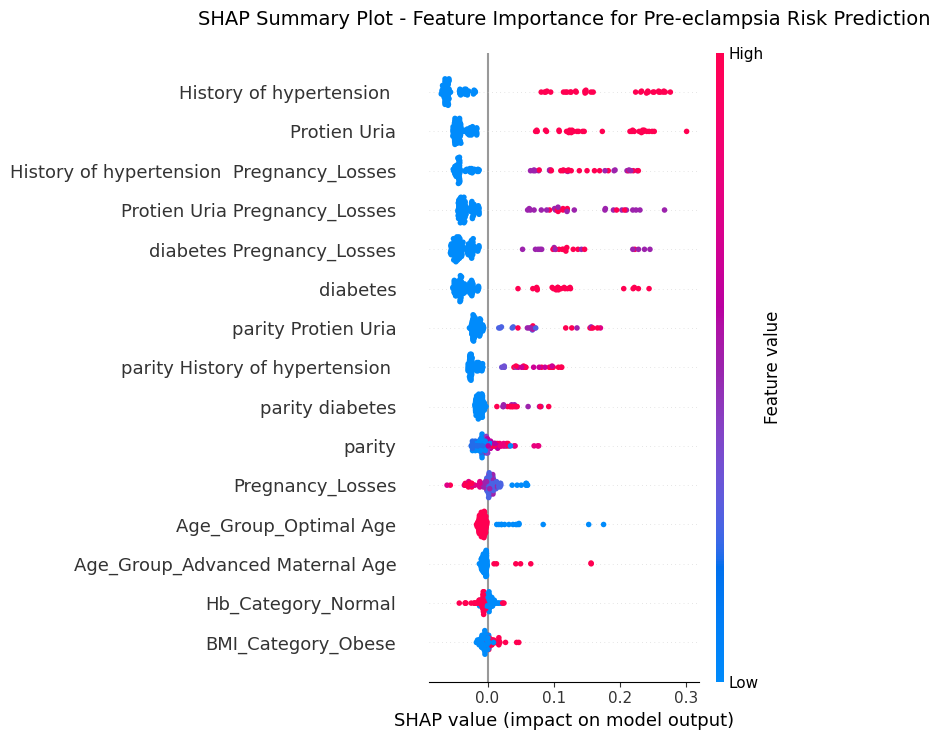

In [757]:
# Create SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_test_transformed[:sample_size], 
                  feature_names=transformed_feature_names,
                  show=False, max_display=15)
plt.title('SHAP Summary Plot - Feature Importance for Pre-eclampsia Risk Prediction', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()


#### SHAP Summary Plot Findings - Key Insights


In [767]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# INPUTS YOU ALREADY HAVE:
#   df  → original dataframe before preprocessing
#   preprocessor → the ColumnTransformer
#   X_test_transformed, shap_values_class1
# ---------------------------------------------------------------

# Get all transformed feature names
all_features = preprocessor.get_feature_names_out()

# Determine original column → transformed column mapping
binary_original = [col for col in df.columns if df[col].dropna().nunique() == 2]
categorical_original = list(preprocessor.transformers_[1][2])  # from your OneHotEncoder section

# Determine which transformed columns are from each original feature
binary_transformed = []
categorical_transformed = []
numeric_transformed = []

for f in all_features:
    base = f.split("__")[-1]  # ColumnTransformer names look like: encoder__diabetes_1

    if base in binary_original:
        binary_transformed.append(f)
    elif any(base.startswith(cat) for cat in categorical_original):
        categorical_transformed.append(f)
    else:
        numeric_transformed.append(f)


# ===============================================================
# SHAP INTERPRETATION
# ===============================================================

shap_vals = shap_values_class1
Xvals = X_test_transformed

records = []

for i, feat in enumerate(all_features):
    shap_col = shap_vals[:, i]
    col_vals = Xvals[:, i]

    # --- Numeric feature ---
    if feat in numeric_transformed:
        direction = np.mean(shap_col)
        interpretation = (
            "Higher values increase risk" if direction > 0 
            else "Higher values decrease risk"
        )

    # --- Binary feature (correct logic) ---
    elif feat in binary_transformed:
        # Original binary values are preserved after scaling:
        # Check median to separate 0 vs 1 cluster
        threshold = np.median(col_vals)

        pos_mean = shap_col[col_vals > threshold].mean()
        neg_mean = shap_col[col_vals <= threshold].mean()
        direction = pos_mean - neg_mean

        interpretation = (
            "Value = 1 increases risk compared to 0" if direction > 0 
            else "Value = 1 decreases risk compared to 0"
        )

    # --- One-hot encoded categorical ---
    elif feat in categorical_transformed:
        on_mean  = shap_col[col_vals == 1].mean() if np.any(col_vals == 1) else 0
        off_mean = shap_col[col_vals == 0].mean() if np.any(col_vals == 0) else 0
        direction = on_mean - off_mean

        interpretation = (
            "This category increases risk" if direction > 0
            else "This category decreases risk"
        )
        
    # Inside your loop
    original_feat = feat.split("__")[-1]  # Extract original column name
    records.append([original_feat, np.mean(np.abs(shap_col)), direction, interpretation])
    #records.append([feat, np.mean(np.abs(shap_col)), direction, interpretation])


df_final = pd.DataFrame(records, columns=["feature", "importance", "direction", "interpretation"])
df_final = df_final.sort_values("importance", ascending=False)

# --------------------------------------------------------------
# GROUP RESULTS BY DIRECTION
# --------------------------------------------------------------

# Threshold to consider something "neutral"
direction_threshold = 0.01

increasing = df_final[df_final["direction"] > direction_threshold]\
    .sort_values("importance", ascending=False)
decreasing = df_final[df_final["direction"] < -direction_threshold]\
    .sort_values("importance", ascending=False)

# All neutral features
neutral = df_final[df_final["direction"].abs() <= direction_threshold] \
    .sort_values("importance", ascending=False)

# Positive-leaning neutral (direction between +0 and +0.01)
neutral_positive = neutral[neutral["direction"] > 0] \
    .sort_values("importance", ascending=False) \
    .head(5)

# Negative-leaning neutral (direction between -0.01 and 0)
neutral_negative = neutral[neutral["direction"] < 0] \
    .sort_values("importance", ascending=False) \
    .head(5)



print("\n================ RISK-INCREASING FEATURES ================")
display(increasing)

print("\n================ RISK-DECREASING FEATURES ================")
display(decreasing)

print("\n========== TOP 5 POSITIVELY-LEANING NEUTRAL ==========")
display(neutral_positive)

print("\n========== TOP 5 NEGATIVELY-LEANING NEUTRAL ==========")
display(neutral_negative)





================ RISK-INCREASING FEATURES ================


,feature,importance,direction,interpretation
2,History of hypertension,0.083564,0.234944,Value = 1 increases risk compared to 0
3,Protien Uria,0.071925,0.208711,Value = 1 increases risk compared to 0
1,diabetes,0.051462,0.161439,Value = 1 increases risk compared to 0
26,Age_Group_Advanced Maternal Age,0.007956,0.075222,This category increases risk
33,BMI_Category_Obese,0.007214,0.014435,This category increases risk
18,MAP_Category_Severe,0.005014,0.039026,This category increases risk



================ RISK-DECREASING FEATURES ================


,feature,importance,direction,interpretation
27,Age_Group_Optimal Age,0.012340,-0.062249,This category decreases risk
37,Hb_Category_Normal,0.007291,-0.011509,This category decreases risk
34,BMI_Category_Overweight,0.006845,-0.014026,This category decreases risk
16,MAP_Category_High,0.001917,-0.015355,This category decreases risk



========== TOP 5 POSITIVELY-LEANING NEUTRAL ==========


,feature,importance,direction,interpretation
13,History of hypertension Pregnancy_Losses,0.062688,0.003211,Higher values increase risk
14,Protien Uria Pregnancy_Losses,0.056155,0.004482,Higher values increase risk
7,parity Protien Uria,0.030525,0.001586,Higher values increase risk
0,parity,0.012752,0.000285,Higher values increase risk
4,Pregnancy_Losses,0.012549,0.001533,Higher values increase risk



========== TOP 5 NEGATIVELY-LEANING NEUTRAL ==========


,feature,importance,direction,interpretation
11,diabetes Pregnancy_Losses,0.054354,-0.009517,Higher values decrease risk
6,parity History of hypertension,0.029419,-0.005670,Higher values decrease risk
5,parity diabetes,0.016598,-0.003874,Higher values decrease risk
9,diabetes History of hypertension,0.005734,-0.001137,Higher values decrease risk
12,History of hypertension Protien Uria,0.005591,-0.001737,Higher values decrease risk


##### Comments:

These Positively-leaning nuetral features are important in the model, but their influence on risk does not show a strong consistent direction.

They have slightly positive SHAP direction values, meaning that in some patient subgroups they tend to increase risk, but the effect size is small and not stable enough to classify them as true risk factors.

In other words:

- They matter to the prediction
- But their effect on increasing risk is weak, subtle, or dependent on interactions with other features

##### Previous Version:

### SHAP for Linear Regression

In [768]:
import shap
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Use LinearRegression as the best model for SHAP analysis
# Get the trained model and preprocessed data
lr_model = lr_clf.named_steps['clf']
preprocessor = lr_clf.named_steps['prep']

# Transform the training data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Create SHAP explainer using TreeExplainer (for RandomForest)
explainer = shap.TreeExplainer(rf_model)

USE_ALL_DATA = True  # Set to True to use all test data instead of sampling

if USE_ALL_DATA:
    sample_size = len(X_test_transformed)
    print(f"Using ALL test data: {sample_size} samples")
    print("This may take longer but gives more comprehensive results.")
else:
    sample_size = min(100, len(X_test_transformed))
    print(f"Sampling {sample_size} samples from {len(X_test_transformed)} test samples")
    print("This is sufficient for accurate feature importance visualization.")
    print("(Set USE_ALL_DATA = True above to use all data)")

# Calculate SHAP values
print(f"\nCalculating SHAP values...")
shap_values = explainer.shap_values(X_test_transformed[:sample_size])
print("Done!")

# Handle different SHAP value formats
# For binary classification, shap_values can be:
# 1. A list with [values_class0, values_class1]
# 2. A 3D numpy array with shape (samples, features, classes)
# 3. A 2D numpy array with shape (samples, features)

print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    # If it's a list, extract class 1 values
    shap_values_class1 = shap_values[1]
    print(f"SHAP values is a list with {len(shap_values)} classes")
elif isinstance(shap_values, np.ndarray):
    if len(shap_values.shape) == 3:
        # 3D array: (samples, features, classes) - extract class 1
        shap_values_class1 = shap_values[:, :, 1]
        print(f"SHAP values is a 3D array with shape {shap_values.shape}")
        print(f"Extracting class 1: shape {shap_values_class1.shape}")
    elif len(shap_values.shape) == 2:
        # 2D array: already in correct format
        shap_values_class1 = shap_values
        print(f"SHAP values is a 2D array with shape {shap_values.shape}")
    else:
        shap_values_class1 = shap_values
        print(f"SHAP values has unexpected shape: {shap_values.shape}")
else:
    shap_values_class1 = shap_values

print(f"\nFinal SHAP values shape: {shap_values_class1.shape}")
print(f"Number of features: {shap_values_class1.shape[1]}")
print(f"Number of samples: {shap_values_class1.shape[0]}")


Using ALL test data: 141 samples
This may take longer but gives more comprehensive results.

Calculating SHAP values...
Done!
SHAP values type: <class 'numpy.ndarray'>
SHAP values is a 3D array with shape (141, 38, 2)
Extracting class 1: shape (141, 38)

Final SHAP values shape: (141, 38)
Number of features: 38
Number of samples: 141


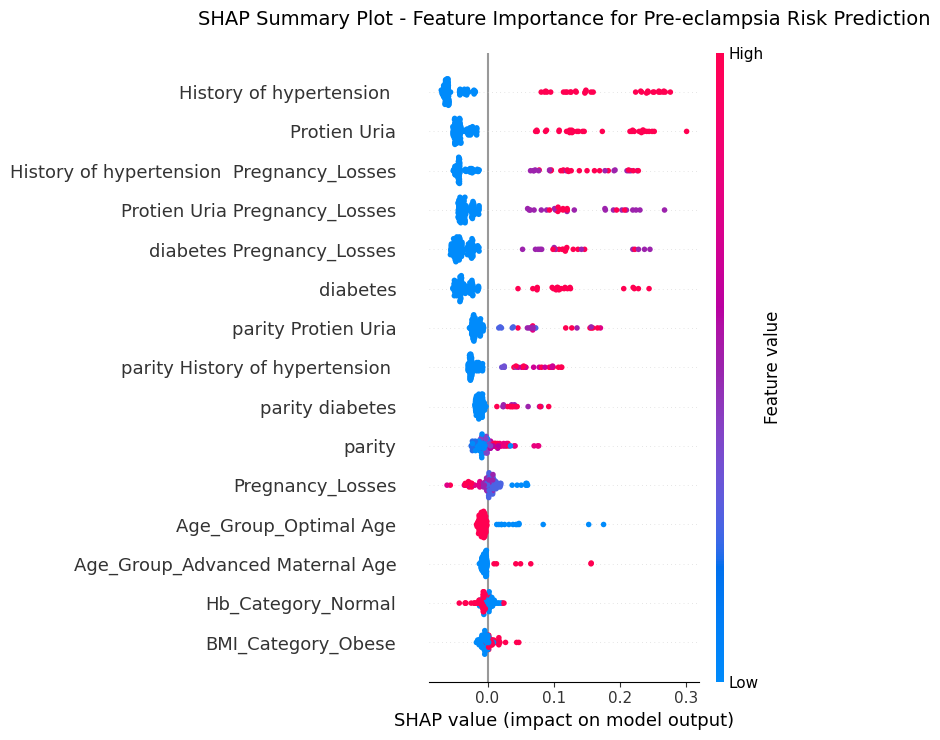

In [769]:
# Create SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_test_transformed[:sample_size], 
                  feature_names=transformed_feature_names,
                  show=False, max_display=15)
plt.title('SHAP Summary Plot - Feature Importance for Pre-eclampsia Risk Prediction', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### Syntehesizing results

In [770]:

import pandas as pd
import numpy as np

# -------------------------------
# INPUTS (existing results)
# -------------------------------
# df_final → SHAP results with columns: ['feature','importance','direction','interpretation']
# rf_df → RF results with columns: ['feature','importance']  # rename to rf_importance



lr_importance = lr_clf.named_steps['clf'].coef_[0]
lr_feature_names = transformed_feature_names

# Create DataFrame for Random Forest importance
lr_df = pd.DataFrame({
    'feature': lr_feature_names,
    'lr_importance': lr_importance
}).sort_values('lr_importance', ascending=False)


lr_df = lr_df.sort_values('lr_importance', ascending=False).reset_index(drop=True)

# Rename RF importance column for clarity
lr_df = lr_df.rename(columns={'importance':'lr_importance'})

# Normalize RF and SHAP Importances
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

lr_df['lr_norm'] = min_max_norm(lr_df['lr_importance'])
df_final['shap_norm'] = min_max_norm(df_final['importance'])

#  Merge RF + SHAP on Feature
combined_df = pd.merge(lr_df, df_final[['feature','shap_norm','direction','interpretation']], 
                       on='feature', how='outer').fillna(0)


# Compute Hybrid Score (Simple Average)
combined_df['hybrid_score'] = (combined_df['lr_norm'] + combined_df['shap_norm']) / 2

# Categorize by SHAP Direction
direction_threshold = 0.01
combined_df['effect'] = np.where(combined_df['direction'] > direction_threshold, 'risk_increasing',
                         np.where(combined_df['direction'] < -direction_threshold, 'risk_decreasing', 'neutral'))

# Sort by Hybrid Score
combined_df = combined_df.sort_values('hybrid_score', ascending=False).reset_index(drop=True)

# View Combined Results
display(combined_df[['feature','shap_norm','lr_norm','hybrid_score','direction','effect','interpretation']])


,feature,shap_norm,lr_norm,hybrid_score,direction,effect,interpretation
0,Protien Uria,0.860403,1.000000,0.930202,0.208711,risk_increasing,Value = 1 increases risk compared to 0
1,History of hypertension,1.000000,0.827951,0.913975,0.234944,risk_increasing,Value = 1 increases risk compared to 0
2,diabetes Pregnancy_Losses,0.649661,0.933290,0.791475,-0.009517,neutral,Higher values decrease risk
3,History of hypertension Pregnancy_Losses,0.749621,0.788413,0.769017,0.003211,neutral,Higher values increase risk
4,diabetes,0.614970,0.692004,0.653487,0.161439,risk_increasing,Value = 1 increases risk compared to 0
5,Protien Uria Pregnancy_Losses,0.671254,0.611996,0.641625,0.004482,neutral,Higher values increase risk
6,parity Protien Uria,0.363856,0.813158,0.588507,0.001586,neutral,Higher values increase risk
7,parity History of hypertension,0.350591,0.697499,0.524045,-0.005670,neutral,Higher values decrease risk
8,Age_Group_Advanced Maternal Age,0.093167,0.909144,0.501155,0.075222,risk_increasing,This category increases risk
9,MAP_Category_Severe,0.057883,0.778542,0.418212,0.039026,risk_increasing,This category increases risk


In [771]:
# Define thresholds for direction
direction_threshold = 0.01 # same as before

# Split into categories
risk_factors = combined_df[combined_df['direction'] > direction_threshold] \
    .sort_values('hybrid_score', ascending=False).reset_index(drop=True)

protective_factors = combined_df[combined_df['direction'] < -direction_threshold] \
    .sort_values('hybrid_score', ascending=False).reset_index(drop=True)

neutral = combined_df[combined_df['direction'].abs() <= direction_threshold] \
    .sort_values('hybrid_score', ascending=False).reset_index(drop=True)
    
neutral_positive = neutral[neutral['direction'] > 0].reset_index(drop=True)
neutral_negative = neutral[neutral['direction'] < 0].reset_index(drop=True)

# Display Results
print("\n================ RISK FACTORS (Increase Risk) ================")
display(risk_factors[['feature','lr_importance','shap_norm','lr_norm','hybrid_score','direction','interpretation']])

print("\n================ PROTECTIVE FACTORS (Decrease Risk) ================")
display(protective_factors[['feature','lr_importance','shap_norm','lr_norm','hybrid_score','direction','interpretation']])

print("\n========== NEUTRAL POSITIVE-LEANING ==========")
display(neutral_positive[['feature','lr_importance','shap_norm','lr_norm','hybrid_score','direction','interpretation']].head())

print("\n========== NEUTRAL NEGATIVE-LEANING ==========")
display(neutral_negative[['feature','lr_importance','shap_norm','lr_norm','hybrid_score','direction','interpretation']].head())



================ RISK FACTORS (Increase Risk) ================


,feature,lr_importance,shap_norm,lr_norm,hybrid_score,direction,interpretation
0,Protien Uria,1.604211,0.860403,1.000000,0.930202,0.208711,Value = 1 increases risk compared to 0
1,History of hypertension,1.112296,1.000000,0.827951,0.913975,0.234944,Value = 1 increases risk compared to 0
2,diabetes,0.723605,0.614970,0.692004,0.653487,0.161439,Value = 1 increases risk compared to 0
3,Age_Group_Advanced Maternal Age,1.344439,0.093167,0.909144,0.501155,0.075222,This category increases risk
4,MAP_Category_Severe,0.971030,0.057883,0.778542,0.418212,0.039026,This category increases risk
5,BMI_Category_Obese,0.474333,0.084267,0.604820,0.344544,0.014435,This category increases risk



================ PROTECTIVE FACTORS (Decrease Risk) ================


,feature,lr_importance,shap_norm,lr_norm,hybrid_score,direction,interpretation
0,Hb_Category_Normal,-0.251724,0.085189,0.350879,0.218034,-0.011509,This category decreases risk
1,BMI_Category_Overweight,-0.457432,0.079836,0.278932,0.179384,-0.014026,This category decreases risk
2,MAP_Category_High,-0.420723,0.020732,0.291771,0.156251,-0.015355,This category decreases risk
3,Age_Group_Optimal Age,-1.254939,0.145746,0.000000,0.072873,-0.062249,This category decreases risk



========== NEUTRAL POSITIVE-LEANING ==========


,feature,lr_importance,shap_norm,lr_norm,hybrid_score,direction,interpretation
0,History of hypertension Pregnancy_Losses,0.999252,0.749621,0.788413,0.769017,0.003211,Higher values increase risk
1,Protien Uria Pregnancy_Losses,0.494849,0.671254,0.611996,0.641625,0.004482,Higher values increase risk
2,parity Protien Uria,1.070001,0.363856,0.813158,0.588507,0.001586,Higher values increase risk
3,parity,0.267453,0.150685,0.532463,0.341574,0.000285,Higher values increase risk
4,AFI_Category_Oligohydramnios,0.322665,0.027542,0.551774,0.289658,0.004832,This category increases risk



========== NEUTRAL NEGATIVE-LEANING ==========


,feature,lr_importance,shap_norm,lr_norm,hybrid_score,direction,interpretation
0,diabetes Pregnancy_Losses,1.413476,0.649661,0.933290,0.791475,-0.009517,Higher values decrease risk
1,parity History of hypertension,0.739315,0.350591,0.697499,0.524045,-0.005670,Higher values decrease risk
2,parity diabetes,0.376356,0.196819,0.570552,0.383686,-0.003874,Higher values decrease risk
3,diabetes Protien Uria,0.113237,0.056952,0.478525,0.267739,-0.001466,Higher values decrease risk
4,diabetes History of hypertension,0.084214,0.066511,0.468375,0.267443,-0.001137,Higher values decrease risk
